In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from collections import Counter
import re


In [3]:
# Read the CSV file

df = pd.read_csv('cleaned_output.csv')

df

,Covidence #,Title,Reviewer Name,Study ID,Journal Subject Area (Scimago classification),What is the type of study?,What are the objectives of the study?,Which RL technique is used?,Which finance application is tested?,What are the stated key results of the study?,...,Are results validated using statistical tests or confidence intervals?,Is the code or workflow made publicly available and referred to?,What is the implementation status?,Does the study conduct a benchmark?,What is the model benchmarked against?,Is a standard dataset used for all models?,Does study mention Transfer Learning or similar method as potential avenue for research?,Does study mention alternative generalization methods?,Does the study propose a framework to structure RL research in finance?,Year
0,496,Portfolio Allocation with Dynamic Risk Prefere...,Consensus,Chen2024b,"Computer Science; Economics, Econometrics and ...",Primary,The paper proposes a reinforcement learning (R...,Policy-based Method,Portfolio Management,The RL-based portfolio outperformed both the b...,...,No,No,Simulation-based,Yes,Market Indexes; Algorithmic Baselines,Yes,No,No,No,2024
1,488,Recent advances in reinforcement learning in f...,Consensus,Hambly2023,"Business, Management and Accounting; Economics...",Secondary,To review recent advancements in reinforcement...,Other: N/A,Other: N/A,RL has shown significant promise in adapting t...,...,No,No,Simulation-based,No,Other: N/A,NaN,Yes,Yes,Yes,2023
2,485,Discrete-Event Simulation-Based Q-Learning Alg...,Consensus,Barbieri 2020,Computer Science,Primary,Combine discrete-event simulation with RL for ...,Value-based Method,Portfolio Management,showcasing benefits of discrete-event simulati...,...,No,No,Simulation-based,No,NaN,NaN,No,No,No,2020
3,477,Take Bitcoin into your portfolio: a novel ense...,Consensus,Li2021,"Business, Management and Accounting; Economics...",Primary,Design a novel ensemble portfolio optimization...,Other: not defined,Portfolio Management,Extended broad commodity asset pool by includi...,...,No,No,Simulation-based,Yes,Market Indexes; Random or Naive Strategies,Yes,No,No,No,2021
4,461,Developing an investment method for securities...,Consensus,Song2024,"Computer Science, Engineering, Materials Science",Primary,Propose and empirically test an investment str...,Actor-Critic Method,Portfolio Management,Introduced analytical approach to assess risk ...,...,No,No,Simulation-based,Yes,Algorithmic Baselines; State of the Art Algori...,Yes,No,Yes,No,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,5,Outperforming algorithmic trading reinforcemen...,Consensus,Felizardo2022,"Computer Science, Engineering",Primary,The study compares reinforcement learning (RL)...,Value-based Method; Policy-based Method; Actor...,Algorithmic Trading,Propose custom supervised learning approach fo...,...,No,Yes,Simulation-based,Yes,Market Indexes; State of the Art Algorithms,Yes,No,No,No,2022
159,4,Deep Reinforcement Learning Robots for Algorit...,Consensus,Park2024b,"Computer Science, Engineering, Materials Science",Primary,Build DRL-based stock trading robots using PPO...,Actor-Critic Method,Algorithmic Trading,Compared two models using single stock and mul...,...,No,No,Simulation-based,Yes,Other: Two versions of proposed model,Yes,No,No,No,2024
160,3,Continuous control with Stacked Deep Dynamic R...,Consensus,Aboussalah 2020,"Computer Science, Engineering",Primary,Develop new RL algorithm for continuous action...,Actor-Critic Method,Portfolio Management,first attempt at continuous control using recu...,...,No,No,Simulation-based,Yes,Random or Naive Strategies; Algorithmic Baselines,Yes,No,No,No,2020
161,2,Crude oil price prediction using deep reinforc...,Consensus,Liang2023,"Economics, Econometrics and Finance; Environme...",Primary,Develop a deep reinforcement learning (DRL) al...,Actor-Critic Method,Other: Commodity Price Forecasting,Introduced improved Ornstein-Uhlenbeck process...,...,No,No,S

# 1 General Analysis

In [4]:
# count number of studies
df.shape[0]

163

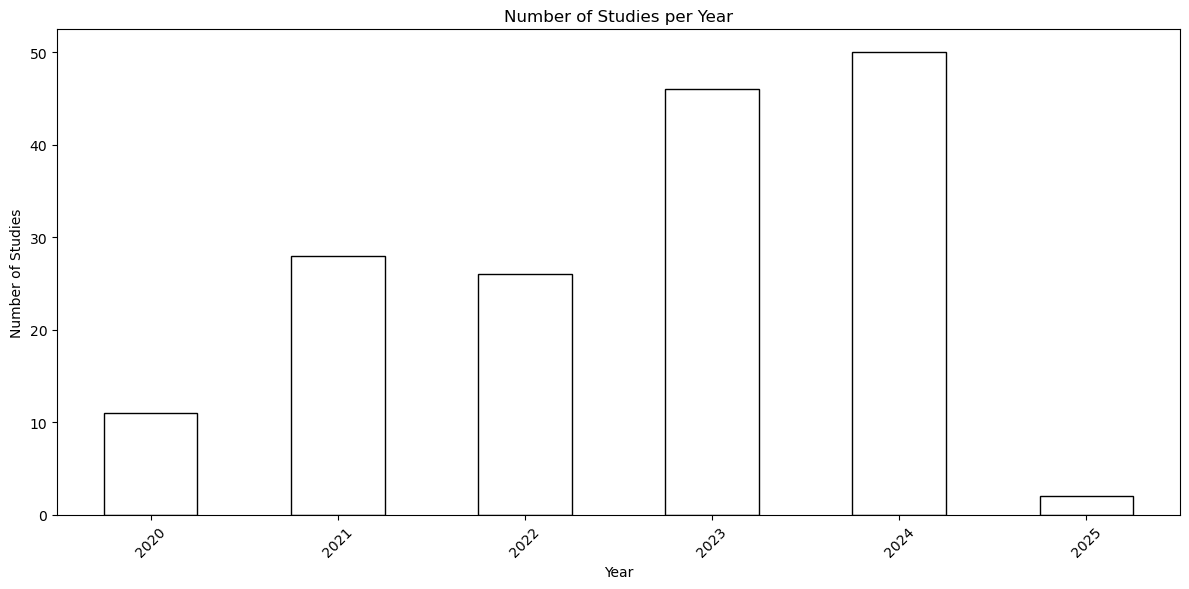

Year
2020    11
2021    28
2022    26
2023    46
2024    50
2025     2
Name: count, dtype: int64

In [5]:
# plot number of studies per year
plt.figure(figsize=(12, 6))
df['Year'].value_counts().sort_index().plot(kind='bar', color='white', edgecolor='black')
plt.title('Number of Studies per Year')
plt.xlabel('Year')
plt.ylabel('Number of Studies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df['Year'].value_counts().sort_index()

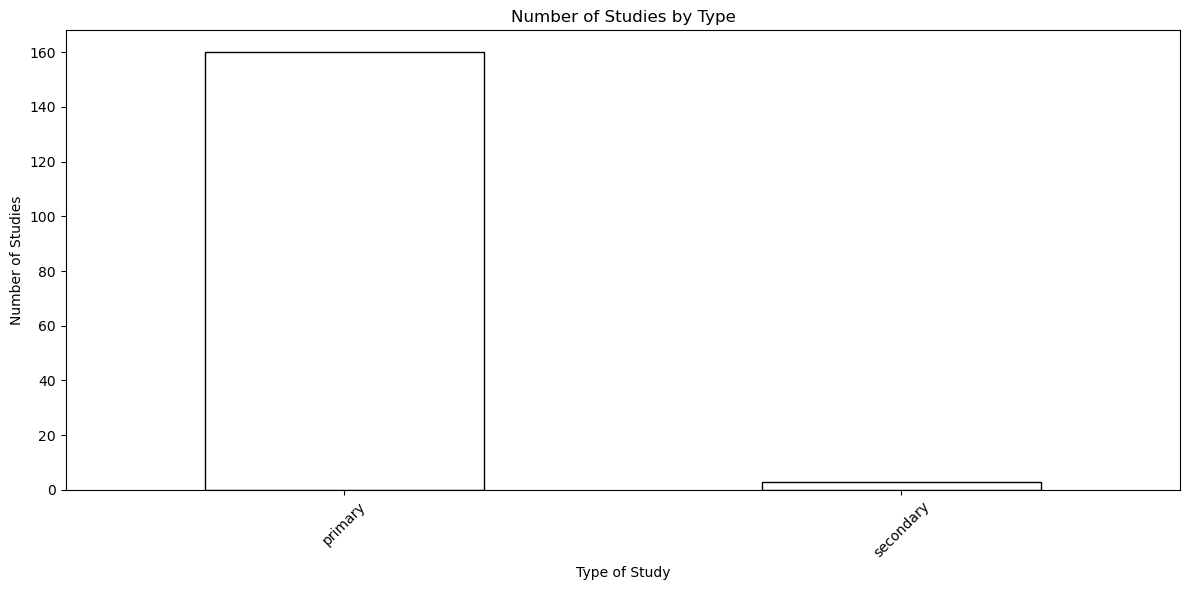

What is the type of study?
primary      160
secondary      3
Name: count, dtype: int64

In [6]:
# make all values in the 'What is the type of study?' column lowercase
df['What is the type of study?'] = df['What is the type of study?'].str.lower().replace('other: primary', 'primary')

# plot by type of study
plt.figure(figsize=(12, 6))
df['What is the type of study?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Number of Studies by Type')
plt.xlabel('Type of Study')
plt.ylabel('Number of Studies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df['What is the type of study?'].value_counts()


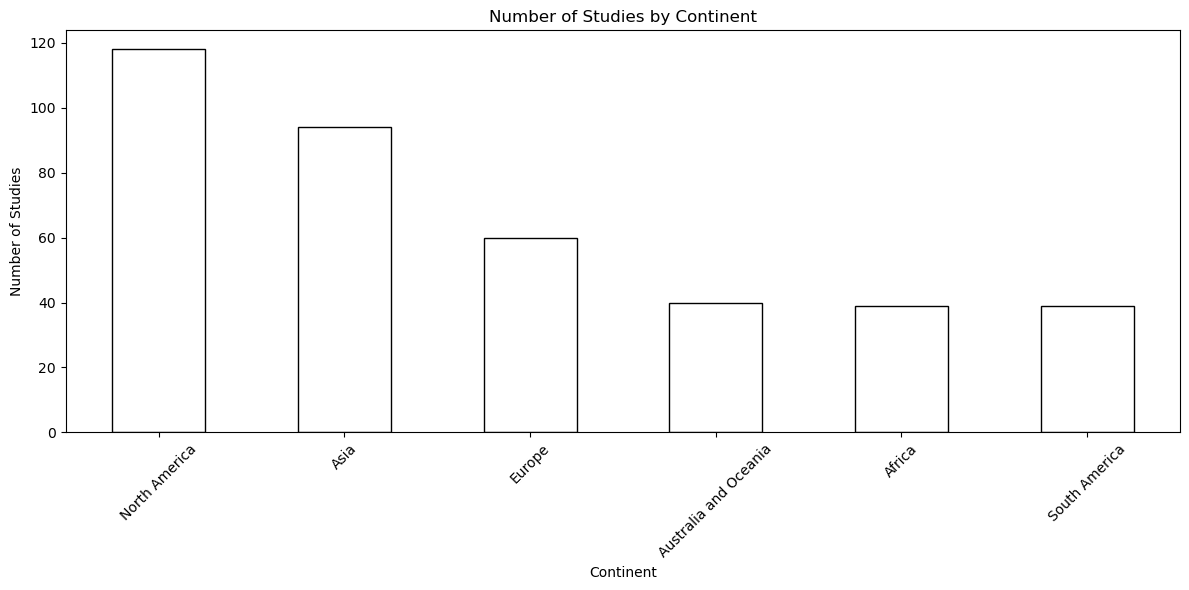

Which continents are represented in the price dataset?
North America            118
Asia                      94
Europe                    60
Australia and Oceania     40
Africa                    39
South America             39
Name: count, dtype: int64

In [7]:
# Filter out crypto-related applications as they are global and not specific to a continent
filtered_df = df[~df['Which finance application is tested?'].str.contains('crypto', case=False, na=False)]

# Extract and clean continent entries
continents_list = (
    filtered_df['Which continents are represented in the price dataset?']
    .dropna()
    .str.split(';')
    .explode()
    .str.strip()
)

# plot for 'Which continents are represented in the price dataset?'
plt.figure(figsize=(12, 6))
continents_list.value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Number of Studies by Continent')
plt.xlabel('Continent')
plt.ylabel('Number of Studies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

continents_list.value_counts()

# 2 Methodological Analysis

In [8]:
# remove sencodary studies
df = df[df['What is the type of study?'] != 'secondary']
df.shape

(160, 40)

## 2.1 RL Techniques

In [9]:
raw_tech = df['Which RL technique is used?']

# split the raw_tech into a list of techniques by splitting on semicolon and stripping whitespace
tech_list = [tech.strip() for sublist in raw_tech for tech in sublist.split(';') if tech.strip()]

# Replace entries containing 'Other' with 'Unspecified/Other'
standardized_techs = [
    'Unspecified/Other' if 'other' in tech.lower() else tech
    for tech in tech_list
]

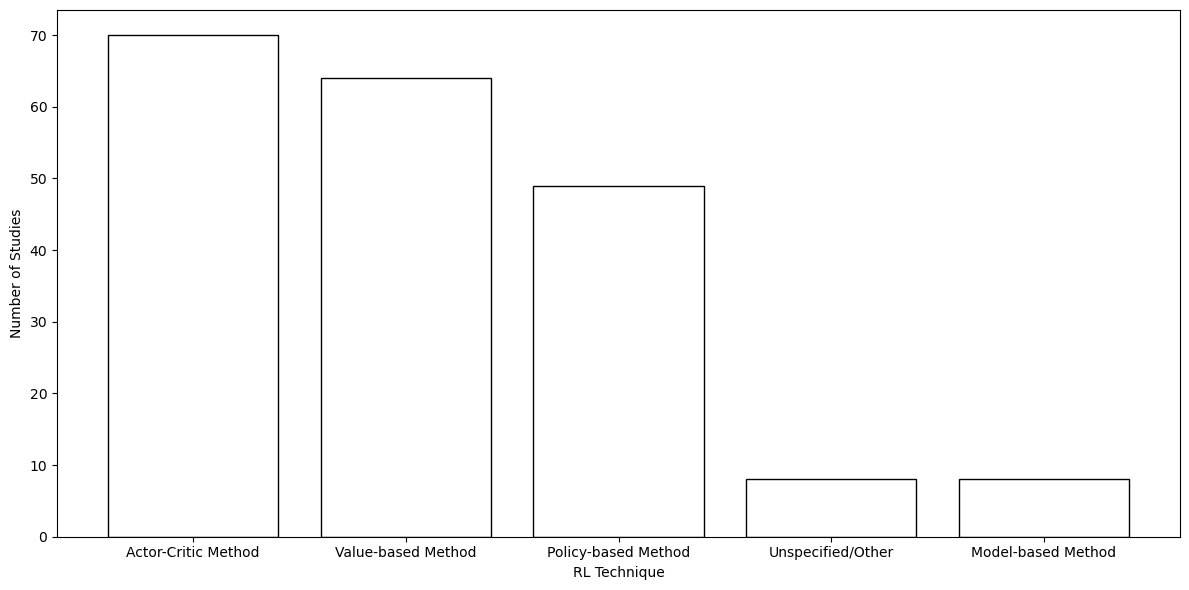

RL Techniques and their counts:
Actor-Critic Method: 70
Value-based Method: 64
Policy-based Method: 49
Unspecified/Other: 8
Model-based Method: 8


In [56]:
# plot tech
tech_counter = Counter(standardized_techs)
# Sort by count (descending)
sorted_tech = sorted(tech_counter.items(), key=lambda x: x[1], reverse=True)
tech_labels, tech_counts = zip(*sorted_tech)

# Plot sorted bar chart
plt.figure(figsize=(12, 6))
plt.bar(tech_labels, tech_counts, color='white', edgecolor='black')
plt.xlabel('RL Technique')
plt.ylabel('Number of Studies')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('images/rl_techniques.png')
plt.show()

# Display the sorted counts
print("RL Techniques and their counts:")
for tech, count in sorted_tech:
    print(f"{tech}: {count}")


In [ ]:
# show studyID and title of rows with actor-critic
print('Studies related to Actor-Critic:')
df[df['Which RL technique is used?'] == 'Actor-Critic Method'][['Study ID', 'Title']]

Studies related to Actor-Critic:


,Study ID,Title
4,Song2024,Developing an investment method for securities...
11,Guarino2022,To learn or not to learn? Evaluating autonomou...
12,Kalina2024,Enhancing Portfolio Performance through Financ...
27,Jaisson2022,Deep differentiable reinforcement learning and...
42,Jeong2023,Safety AARL: Weight adjustment for reinforceme...
43,Tsantekidis2023,Modeling limit order trading with a continuous...
47,Yang2022,A Selective Portfolio Management Algorithm wit...
48,Li2024b,Toward Automatic Market Making: An Imitative R...
51,Li2022,Ensemble Investment Strategies Based on Reinfo...
54,Marzban2023a,Deep reinforcement learning for option pricing...


In [53]:
# show studyID and title of rows with value-based methods
print('Studies related to Value-Based Methods:')
df[df['Which RL technique is used?'] == 'Value-based Method'][['Study ID', 'Title']]

Studies related to Value-Based Methods:


,Study ID,Title
2,Barbieri 2020,Discrete-Event Simulation-Based Q-Learning Alg...
5,Muminov2024,Enhanced Bitcoin Price Direction Forecasting W...
8,Carta 2021a,A multi-layer and multi-ensemble stock trader ...
9,Dai2023,Learning equilibrium mean-variance strategy
10,Huang2023,DADE-DQN: Dual Action and Dual Environment Dee...
13,Anuradha 2021,Big data based stock trend prediction using de...
14,Harnpadungkij2022,Risk-Sensitive Portfolio Management by Using C...
16,Park2020,An intelligent financial portfolio trading str...
18,Liu2022,Multi-type data fusion framework based on deep...
23,Li2023c,Integrating Social Media Data and Historical S...


In [54]:
# show studyID and title of rows with model-based methods
print('Studies related to Model-Based Methods:')
df[df['Which RL technique is used?'] == 'Model-based Method'][['Study ID', 'Title']]

Studies related to Model-Based Methods:


,Study ID,Title
26,Ni2024,Portfolio optimization by enhanced LinUCB
75,Huang2023,Model-based reinforcement learning with non-Ga...
76,Zou2024,A novel Deep Reinforcement Learning based auto...
101,Kang2024,Development of an AI framework using neural pr...
103,Ni2023,Contextual combinatorial bandit on portfolio m...
122,Song2022,Design and Application of Financial Market Opt...


## 2.2 Finance Applications

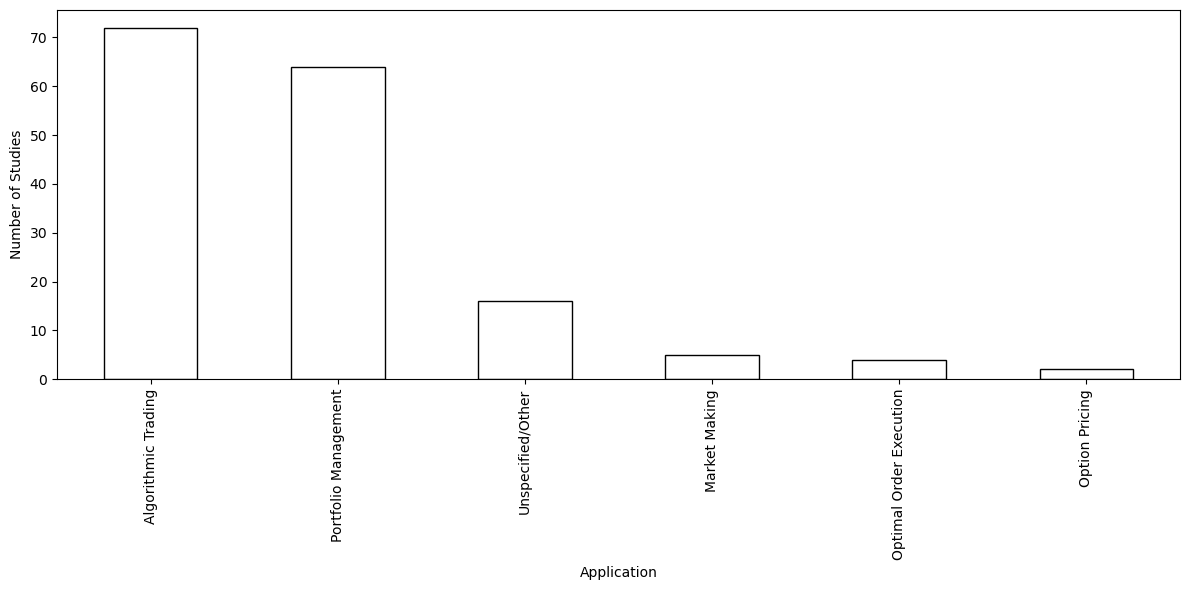

Which finance application is tested?
Algorithmic Trading        72
Portfolio Management       64
Unspecified/Other          16
Market Making               5
Optimal Order Execution     4
Option Pricing              2
Name: count, dtype: int64

In [57]:
# Replace rows containing 'other' (case-insensitive) with 'Unspecified/Other'
mask = df['Which finance application is tested?'].str.contains('other', case=False, na=False)
df.loc[mask, 'Which finance application is tested?'] = 'Unspecified/Other'


# plot bar plot for 'Which finance application is tested?'

plt.figure(figsize=(12, 6))
df['Which finance application is tested?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.xlabel('Application')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('images/applications.png')
plt.show()
# Count the occurrences of each application
df['Which finance application is tested?'].value_counts()

In [12]:
# show studyID and title of rows with algorithmic trading
print('Studies related to Algorithmic Trading:')
df[df['Which finance application is tested?'] == 'Algorithmic Trading'][['Study ID', 'Title']]

Studies related to Algorithmic Trading:


,Study ID,Title
8,Carta 2021a,A multi-layer and multi-ensemble stock trader ...
10,Huang2023,DADE-DQN: Dual Action and Dual Environment Dee...
11,Guarino2022,To learn or not to learn? Evaluating autonomou...
17,Kim2022,Hybrid Deep Reinforcement Learning for Pairs T...
18,Liu2022,Multi-type data fusion framework based on deep...
...,...,...
154,He2024,High-Frequency Quantitative Trading of Digital...
156,Tran2023,Optimizing Automated Trading Systems with Deep...
158,Felizardo2022,Outperforming algorithmic trading reinforcemen...
159,Park2024b,Deep Reinforcement Learning Robots for Algorit...


In [51]:
# show studyID and title of rows with portfolio management
print('Studies related to Portfolio Management:')
df[df['Which finance application is tested?'] == 'Portfolio Management'][['Study ID', 'Title']]

Studies related to Portfolio Management:


,Study ID,Title
0,Chen2024b,Portfolio Allocation with Dynamic Risk Prefere...
2,Barbieri 2020,Discrete-Event Simulation-Based Q-Learning Alg...
3,Li2021,Take Bitcoin into your portfolio: a novel ense...
4,Song2024,Developing an investment method for securities...
9,Dai2023,Learning equilibrium mean-variance strategy
...,...,...
150,Du2024,Reinforcement Learning-Based Multimodal Model ...
152,Li2024a,Deep Reinforcement Learning Model for Stock Po...
153,Su2024,A Deep Reinforcement Learning Approach for Por...
155,Liu2024b,Revolutionising Financial Portfolio Management...


## 2.3 Asset Classes

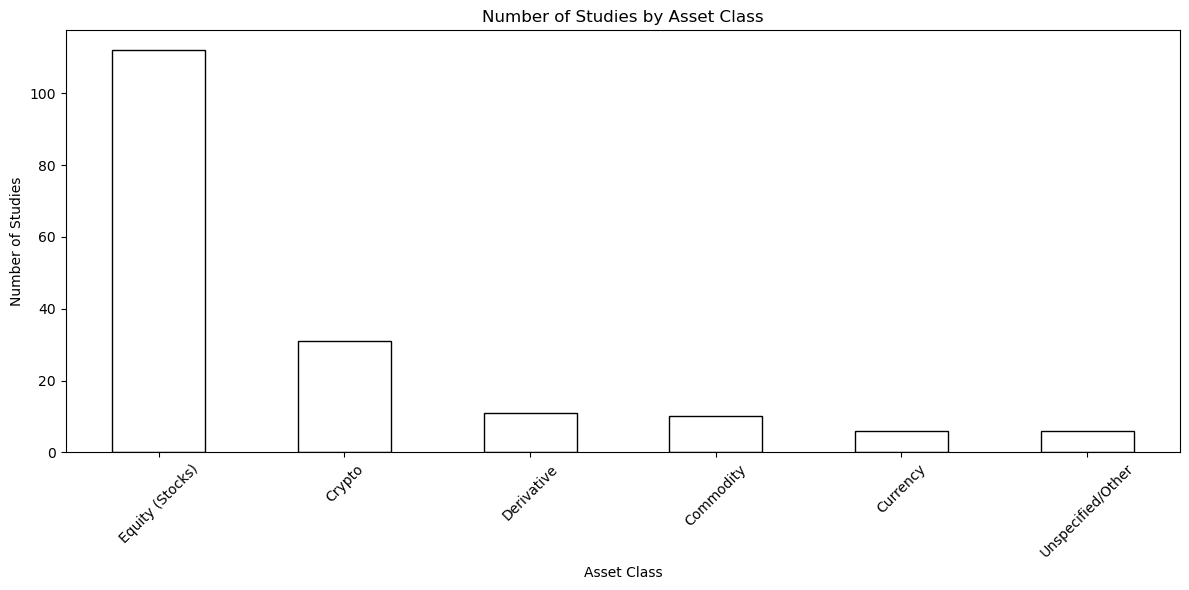

What asset classes are in the dataset?
Equity (Stocks)      112
Crypto                31
Derivative            11
Commodity             10
Currency               6
Unspecified/Other      6
Name: count, dtype: int64

In [13]:

# Replace rows containing 'other' (case-insensitive) with 'Unspecified/Other'
mask = df['What asset classes are in the dataset?'].str.contains('other', case=False, na=False)
df.loc[mask, 'What asset classes are in the dataset?'] = 'Unspecified/Other'

# plot number of asset classes for  'What asset classes are in the dataset?'
asset_classes = df['What asset classes are in the dataset?'].dropna().str.split(';').explode().str.strip()
plt.figure(figsize=(12, 6))
asset_classes.value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Number of Studies by Asset Class')
plt.xlabel('Asset Class')
plt.ylabel('Number of Studies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Count the occurrences of each asset class
asset_classes.value_counts()

In [66]:
# Filter FOR the claim: Equity + Developed Markets (NA, Europe) + Daily Data
for_claim = df[
    (df['What asset classes are in the dataset?'].str.contains('equity', case=False, na=False)) &
    (df['Which continents are represented in the price dataset?'].str.contains('NA|Europe', case=False, na=False)) &
    (df['What is the granularity of the price dataset?'].str.contains('day', case=False, na=False))
][['Study ID', 'Title']]

# Filter AGAINST the claim: Crypto, Derivatives, Commodities, Currencies OR non-NA/Europe OR not daily
against_claim = df[
    (df['What asset classes are in the dataset?'].str.contains('crypto|derivatives|commodities|currencies', case=False, na=False)) |
    (~df['Which continents are represented in the price dataset?'].str.contains('NA|Europe', case=False, na=False)) |
    (~df['What is the granularity of the price dataset?'].str.contains('daily', case=False, na=False))
][['Study ID', 'Title']]

# Display
print("Examples FOR the claim:")
print(for_claim)

print("\nExamples AGAINST the claim:")
print(against_claim)


Examples FOR the claim:
          Study ID                                              Title
2    Barbieri 2020  Discrete-Event Simulation-Based Q-Learning Alg...
3           Li2021  Take Bitcoin into your portfolio: a novel ense...
10       Huang2023  DADE-DQN: Dual Action and Dual Environment Dee...
12      Kalina2024  Enhancing Portfolio Performance through Financ...
13   Anuradha 2021  Big data based stock trend prediction using de...
35          Xu2022  Stock movement prediction via gated recurrent ...
38         Cui2024  Multi-period portfolio optimization using a de...
45         Lee2023  Offline Reinforcement Learning for Automated S...
61       Chen2024c  A Stock Market Decision-Making Framework Based...
74         Kim2023  HADAPS: Hierarchical Adaptive Multi-Asset Port...
76         Zou2024  A novel Deep Reinforcement Learning based auto...
80      Huang2024d  Improving algorithmic trading consistency via ...
85      Cortes2024  Portfolio construction using explainable reinf

In [73]:

# Extract numeric time frame safely
df['time_frame_numeric'] = df['What is the time frame of time series data used?:'] \
    .astype(str) \
    .str.extract(r'(\d+)')[0] \
    .astype(float)

# FOR the claim — loosen conditions to OR logic to get candidates
for_claim = df[
    (
        df['Is dataset quality discussed in article?'].str.contains('no', case=False, na=False)
    ) |
    (
        df['What other datasets are used in the study?'].isna() |
        (df['What other datasets are used in the study?'].str.strip() == '')
    ) |
    (
        df['time_frame_numeric'] < 2000
    )
][['Study ID', 'Title']]


# Relax condition to any two out of three using sum of booleans
against_claim = df[
    (
        df['Is dataset quality discussed in article?'].str.contains('yes', case=False, na=False).fillna(False).astype(int) +
        (df['What other datasets are used in the study?'].str.strip() != '').fillna(False).astype(int) +
        (df['time_frame_numeric'] >= 2000).fillna(False).astype(int)
    ) >= 2
][['Study ID', 'Title']]

print("Examples FOR the claim:")
print(for_claim)

print("Examples AGAINST the claim (relaxed conditions):")
print(against_claim)


Examples FOR the claim:
            Study ID                                              Title
0          Chen2024b  Portfolio Allocation with Dynamic Risk Prefere...
1         Hambly2023  Recent advances in reinforcement learning in f...
2      Barbieri 2020  Discrete-Event Simulation-Based Q-Learning Alg...
3             Li2021  Take Bitcoin into your portfolio: a novel ense...
4           Song2024  Developing an investment method for securities...
..               ...                                                ...
156         Tran2023  Optimizing Automated Trading Systems with Deep...
158    Felizardo2022  Outperforming algorithmic trading reinforcemen...
160  Aboussalah 2020  Continuous control with Stacked Deep Dynamic R...
161        Liang2023  Crude oil price prediction using deep reinforc...
162           Lu2022  Structural break-aware pairs trading strategy ...

[147 rows x 2 columns]
Examples AGAINST the claim (relaxed conditions):
             Study ID                  

## 2.4 Number of Assets

Number of studies with asset data: 156
Minimum number of assets: 1
Maximum number of assets: 4788
Mean number of assets: 71.88
Median number of assets: 10.00
First quartile (Q1) of number of assets: 3.00
Third quartile (Q3) of number of assets: 33.50
Interquartile range (IQR) of number of assets: 30.50


C:\Users\JanderM\AppData\Local\Temp\ipykernel_31652\936393606.py:13: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, max(num_asset_list) + 10)  # Adjust x-axis limit for better visibility


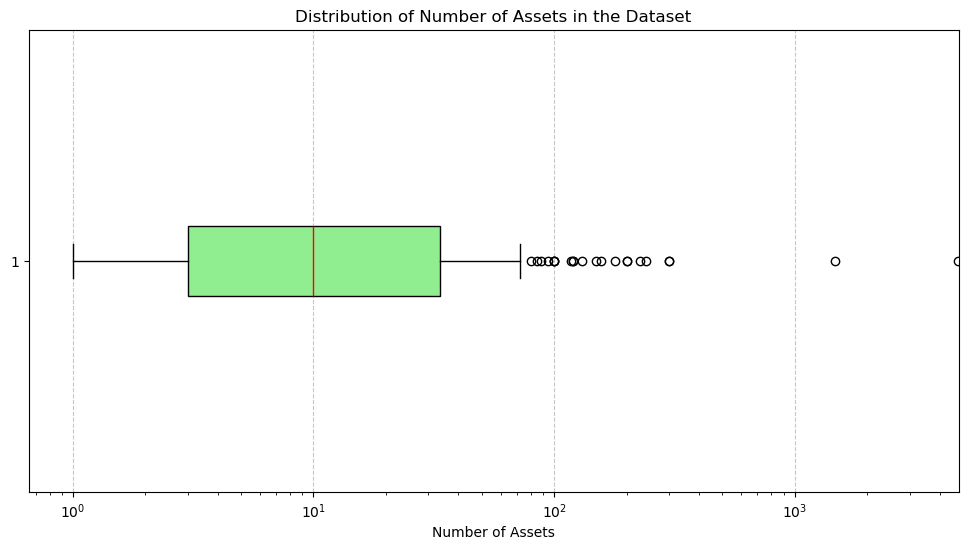

In [14]:
num_asset_list = df['What are the number of assets in the dataset?'].tolist()

# Convert the list of strings to a list of integers and drop NaN values
num_asset_list = [int(x) for x in num_asset_list if isinstance(x, str) and x.isdigit()]


# create box plot for number of assets
plt.figure(figsize=(12, 6))
plt.boxplot(num_asset_list, vert=False, patch_artist=True, boxprops=dict(facecolor='lightgreen', color='black'), medianprops=dict(color='red')) 
plt.xscale('log')  # Use logarithmic scale for better visibility
plt.title('Distribution of Number of Assets in the Dataset')
plt.xlabel('Number of Assets')
plt.xlim(0, max(num_asset_list) + 10)  # Adjust x-axis limit for better visibility
plt.grid(axis='x', linestyle='--', alpha=0.7)
print(f"Number of studies with asset data: {len(num_asset_list)}")

# print the mean and median of the number of assets
mean_assets = np.mean(num_asset_list)
median_assets = np.median(num_asset_list)
max_assets = np.max(num_asset_list)
min_assets = np.min(num_asset_list)

# Calculate quartiles and IQR
first_quartile = np.percentile(num_asset_list, 25)
third_quartile = np.percentile(num_asset_list, 75)
iqr = third_quartile - first_quartile

print(f"Minimum number of assets: {min_assets}")
print(f"Maximum number of assets: {max_assets}")
print(f"Mean number of assets: {mean_assets:.2f}")
print(f"Median number of assets: {median_assets:.2f}")

print(f"First quartile (Q1) of number of assets: {first_quartile:.2f}")
print(f"Third quartile (Q3) of number of assets: {third_quartile:.2f}")
print(f"Interquartile range (IQR) of number of assets: {iqr:.2f}")



## 2.5 Nature of Asset Price  Dataset

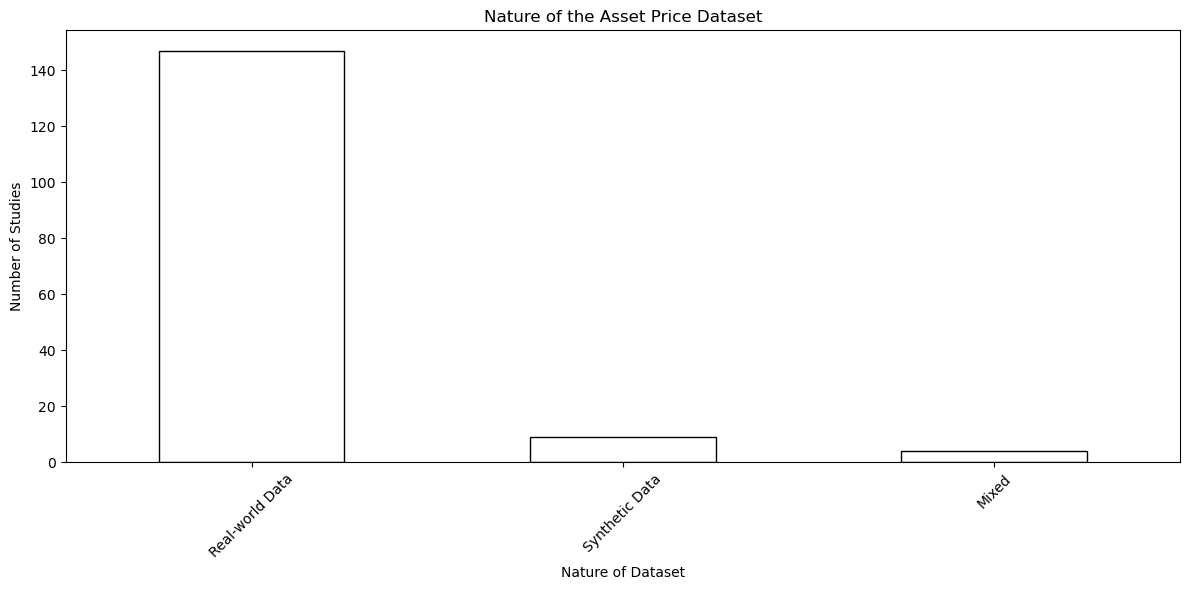

What is the nature of the asset price dataset?
Real-world Data    147
Synthetic Data       9
Mixed                4
Name: count, dtype: int64

In [15]:
# replace other with unspecified/other
mask = df['What is the nature of the asset price dataset?'].str.contains('other', case=False, na=False)
df.loc[mask, 'What is the nature of the asset price dataset?'] = 'Not Applicable'

# box plot for 'What is the nature of the asset price dataset?'
plt.figure(figsize=(12, 6))
df['What is the nature of the asset price dataset?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Nature of the Asset Price Dataset')
plt.xlabel('Nature of Dataset')
plt.ylabel('Number of Studies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Count the occurrences of each nature of dataset
df['What is the nature of the asset price dataset?'].value_counts()

## 2.6 Granularity of Price Dataset

In [16]:
# turn df['What is the granularity of the price dataset?'] into list of strings
granularity_list = df['What is the granularity of the price dataset?'].dropna().str.split(';').explode().str.strip().str.split(',').explode().str.strip()

# standardize to 'minute
granularity_list = granularity_list.str.lower()
granularity_list = granularity_list.str.replace(r'\b(mins?|minutes?)\b', 'minute', regex=True)


# Remove 'Other: ' prefix from granularity_list
granularity_list = granularity_list.replace({'Other: ':''}, regex=True)

# standardize version of 'ticker' to "tick level"
granularity_list = granularity_list.apply(lambda x: 'tick level' if 'tick' in x.lower() else x)

# replace 'daily' with 'day'
granularity_list = granularity_list.apply(lambda x: 'day' if 'daily' in x.lower() else x)

# replace 'hourly' with 'hour'
granularity_list = granularity_list.apply(lambda x: 'hour' if 'hourly' in x.lower() else x)


# make all values lowercase
granularity_list = granularity_list.str.lower()

granularity_list.value_counts()

What is the granularity of the price dataset?
day                    108
hour                    10
minute                  10
30 minute                5
real-time orderbook      5
not specified            4
tick level               4
5 minute                 3
15 minute                3
monthly                  2
500 milisecond           2
second                   2
3 second                 1
milisecond               1
Name: count, dtype: int64

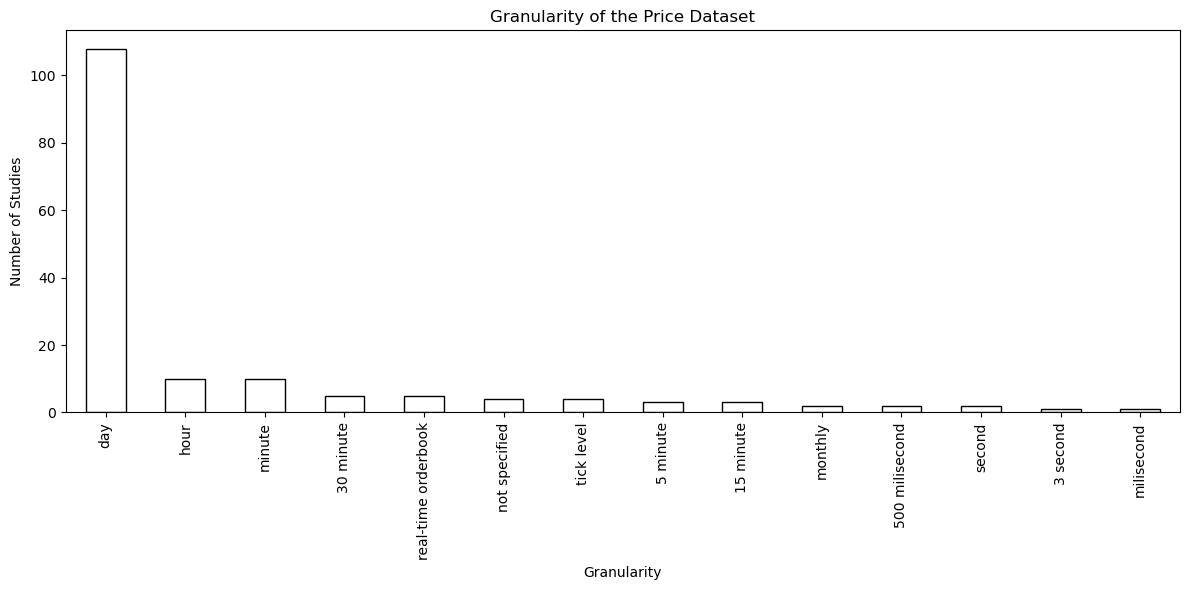

In [17]:
# plot for 'What is the granularity of the price dataset?'
plt.figure(figsize=(12, 6))
granularity_list.value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Granularity of the Price Dataset')
plt.xlabel('Granularity')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## 2.7 Format of Price Dataset

In [18]:
# standardize all values of 'What is the format of the price dataset?' containing 'other' to 'Unspecified/Other'
mask = df['What is the format of the price dataset?'].str.contains('other', case=False, na=False)
df.loc[mask, 'What is the format of the price dataset?'] = 'Unspecified/Other'

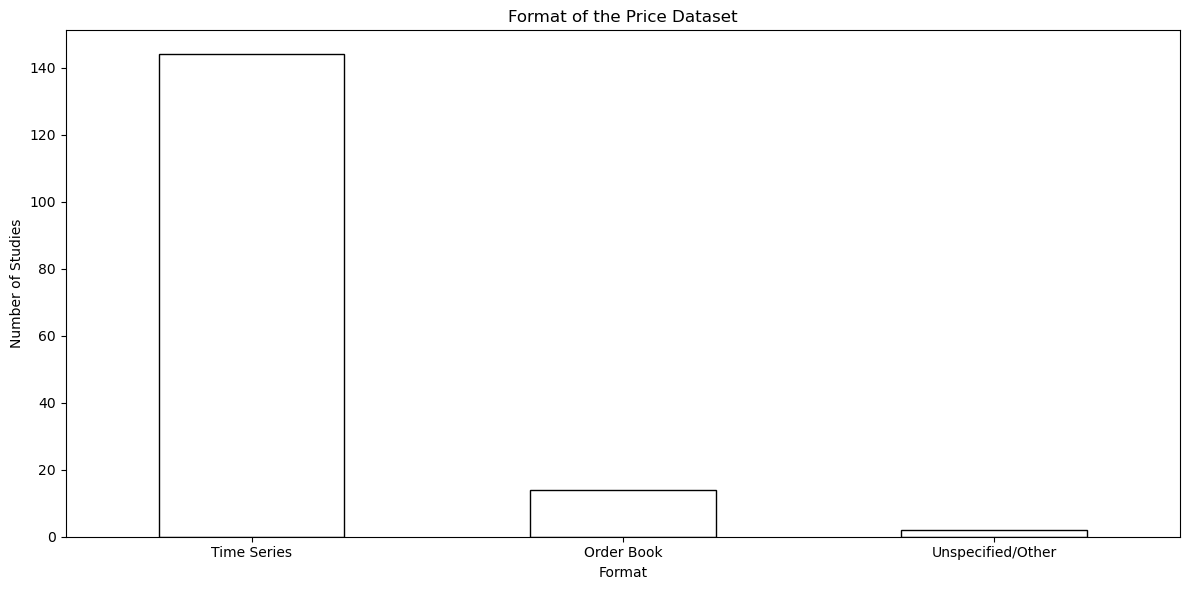

What is the format of the price dataset?
Time Series          144
Order Book            14
Unspecified/Other      2
Name: count, dtype: int64

In [19]:
# plot for  'What is the format of the price dataset?'
plt.figure(figsize=(12, 6))
df['What is the format of the price dataset?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Format of the Price Dataset')
plt.xlabel('Format')
plt.ylabel('Number of Studies')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# Count the occurrences of each format
df['What is the format of the price dataset?'].value_counts()


## 2.8 Other Datasets Used

In [20]:
# turn 'What other datasets are used in the study?' into list of strings
datasets_list = df['What other datasets are used in the study?'].dropna().str.split(';').explode().str.strip().str.split(',').explode().str.strip()

# remove 'Other: ' prefix from datasets_list
datasets_list = datasets_list.replace({'Other: ': ''}, regex=True)

datasets_list.value_counts()

What other datasets are used in the study?
Market Data          62
News Data             7
Fundamental Data      7
Social Media Data     5
Economic Data         4
Search Data           3
Emissions Data        1
Sentiment Data        1
Text comments         1
Image Data            1
Name: count, dtype: int64

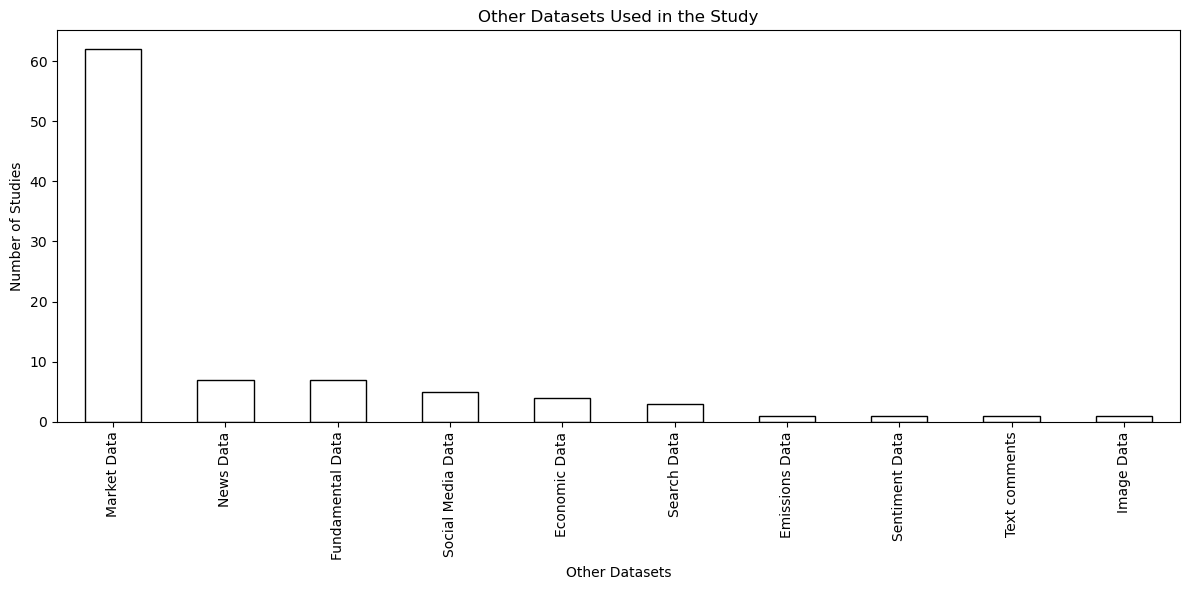

In [21]:
# plot for 'What other datasets are used in the study?'
plt.figure(figsize=(12, 6))
datasets_list.value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Other Datasets Used in the Study')
plt.xlabel('Other Datasets')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 2.9 Timeframe of Dataset

C:\Users\JanderM\AppData\Local\Temp\ipykernel_31652\925098969.py:3: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date Start"] = pd.to_datetime(df["Date Start"], errors='coerce')
C:\Users\JanderM\AppData\Local\Temp\ipykernel_31652\925098969.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Date Start"] = pd.to_datetime(df["Date Start"], errors='coerce')
C:\Users\JanderM\AppData\Local\Temp\ipykernel_31652\925098969.py:4: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date End"] = pd.to_datetime(df["Date E

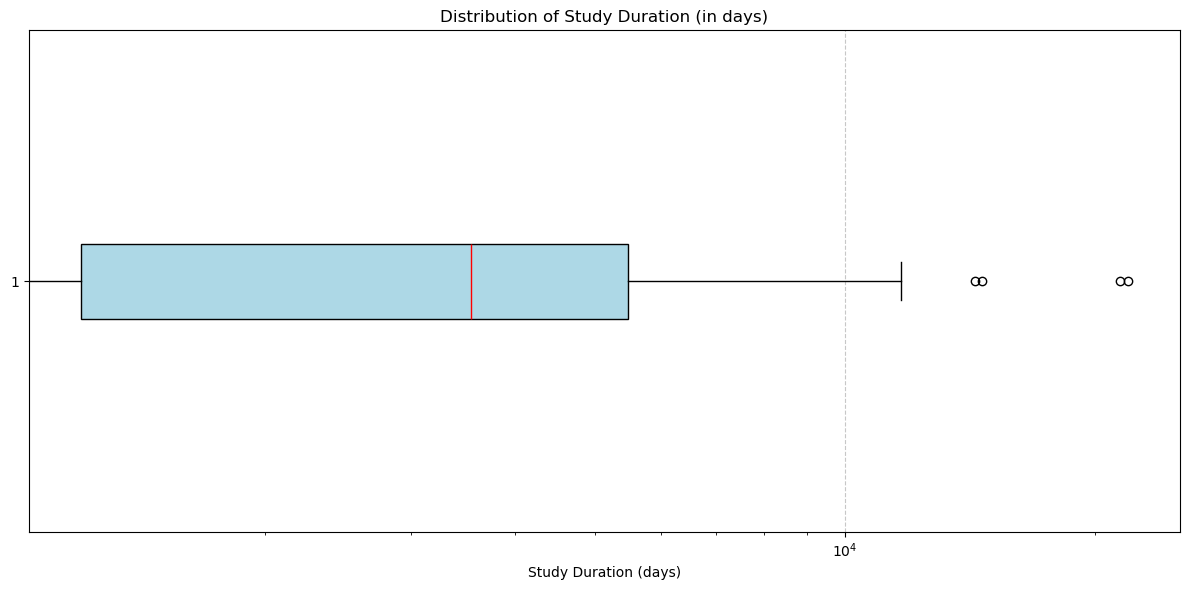

Minimum study duration: 0.0 days
Maximum study duration: 21914.0 days
Mean study duration: 3810.23 days
Median study duration: 3542.00 days
First quartile (Q1) of study duration: 1201.50 days
Third quartile (Q3) of study duration: 5477.50 days
Interquartile range (IQR) of study duration: 4276.00 days


In [22]:
# plot for

df["Date Start"] = pd.to_datetime(df["Date Start"], errors='coerce')
df["Date End"] = pd.to_datetime(df["Date End"], errors='coerce')

# plot boxplot of study duration
plt.figure(figsize=(12, 6))
df['Duration'] = (df['Date End'] - df['Date Start']).dt.days
plt.boxplot(df['Duration'].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue', color='black'), medianprops=dict(color='red'))
plt.title('Distribution of Study Duration (in days)')
plt.xlabel('Study Duration (days)')
plt.xscale('log')  # Use logarithmic scale for better visibility
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# print min, max, mean, median of study duration
min_duration = df['Duration'].min()
max_duration = df['Duration'].max()
mean_duration = df['Duration'].mean()
median_duration = df['Duration'].median()

# add quartiles and IQR
first_quartile_duration = df['Duration'].quantile(0.25)
third_quartile_duration = df['Duration'].quantile(0.75)
iqr_duration = third_quartile_duration - first_quartile_duration

print(f"Minimum study duration: {min_duration} days")
print(f"Maximum study duration: {max_duration} days")
print(f"Mean study duration: {mean_duration:.2f} days")
print(f"Median study duration: {median_duration:.2f} days")

print(f"First quartile (Q1) of study duration: {first_quartile_duration:.2f} days")
print(f"Third quartile (Q3) of study duration: {third_quartile_duration:.2f} days")
print(f"Interquartile range (IQR) of study duration: {iqr_duration:.2f} days")

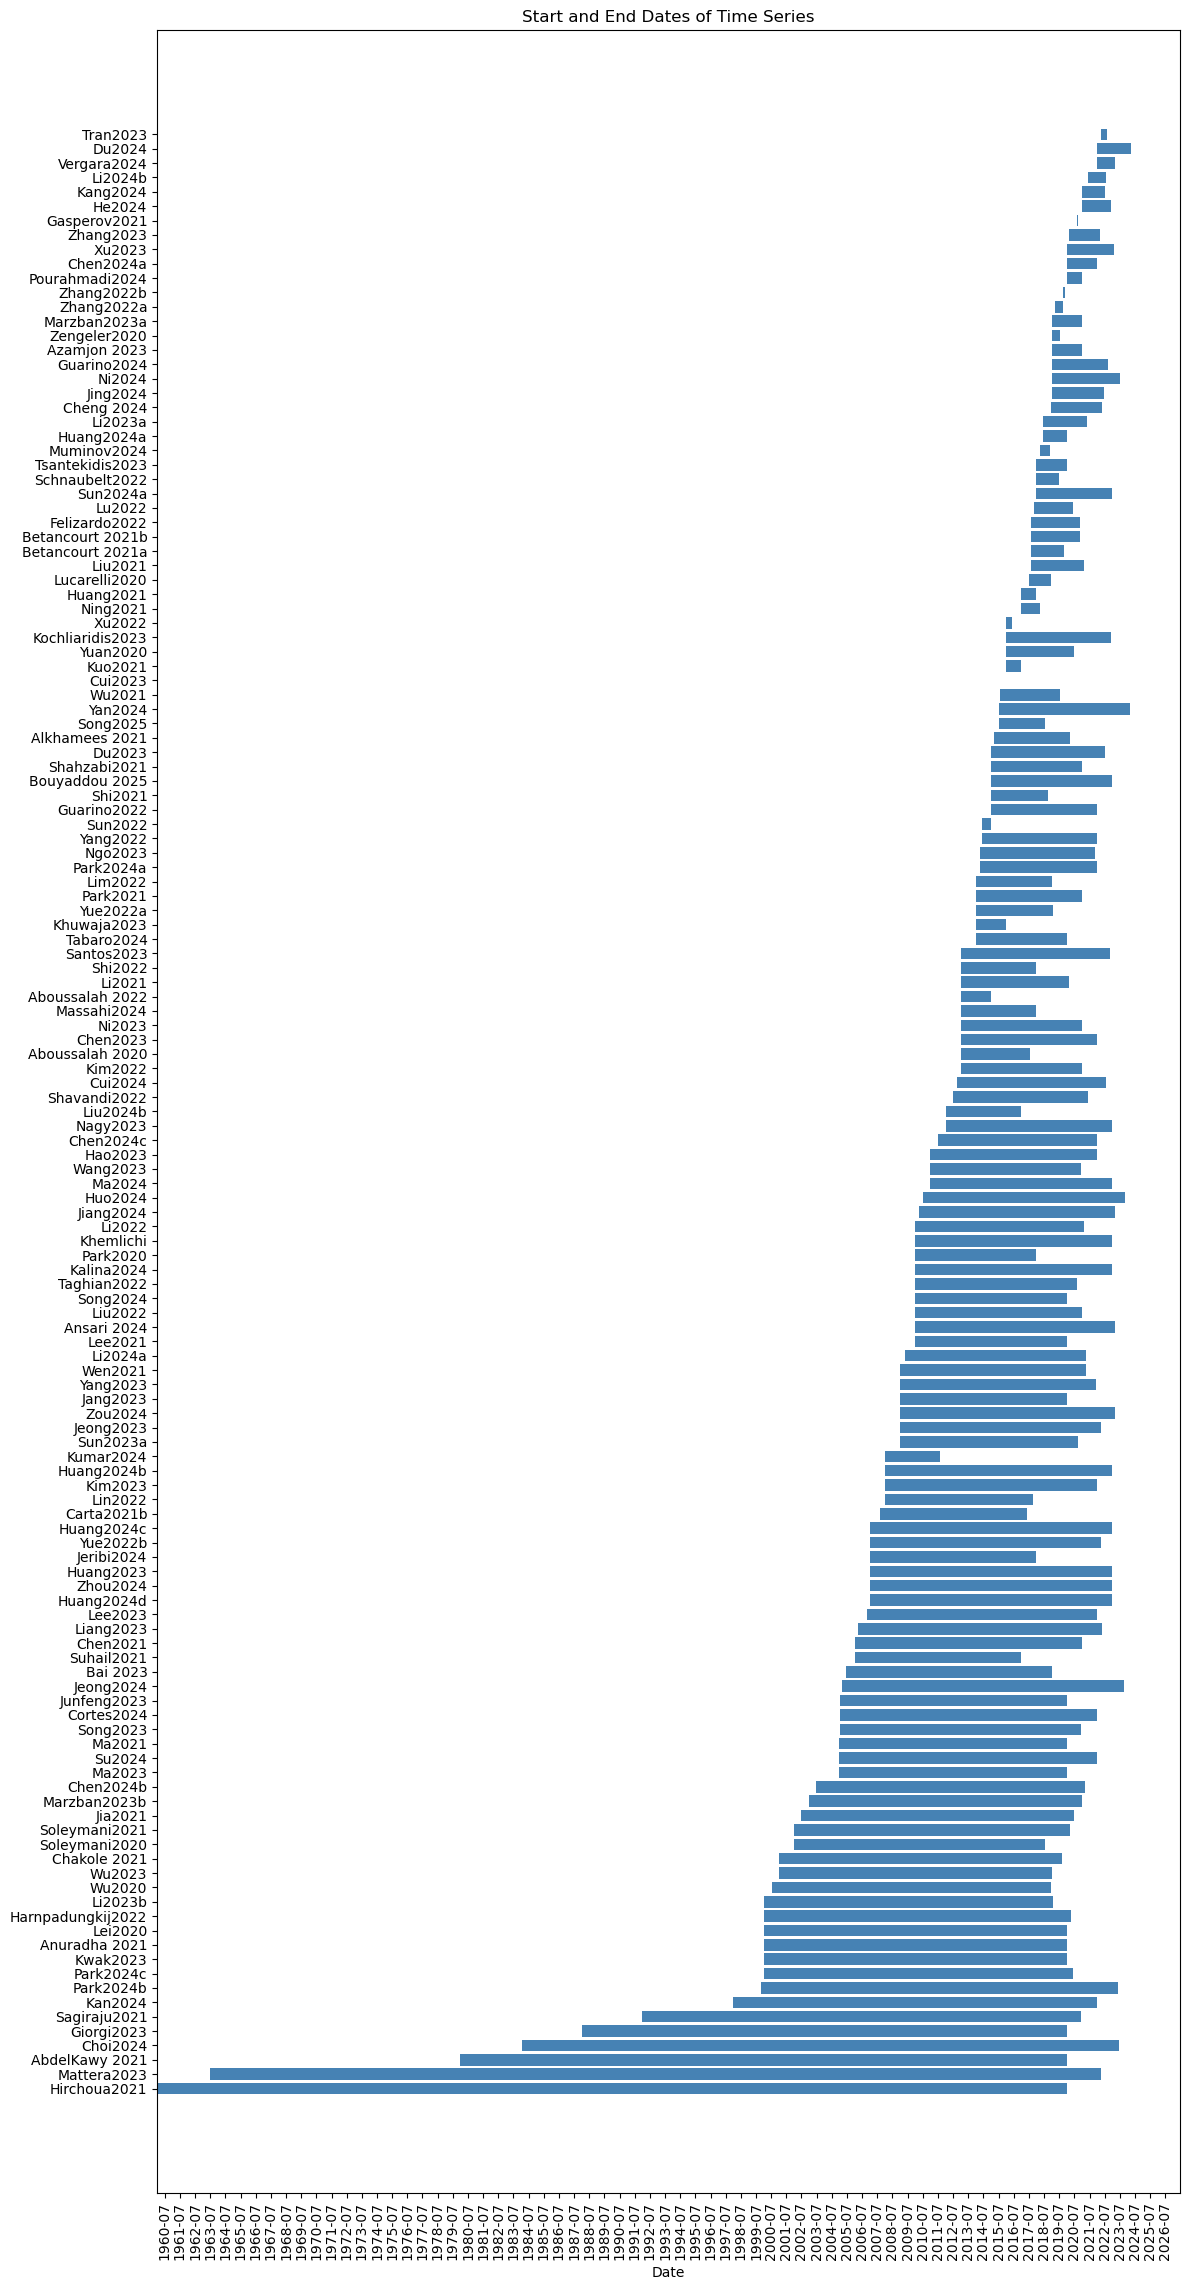

139 studies with start and end dates


In [23]:

# Sort by start date (optional)
time_df = df.sort_values('Date Start')

# drop rows with NaT in 'Date Start' or 'Date End'
time_df = time_df.dropna(subset=['Date Start', 'Date End'])

n = time_df.shape[0]

# Plot
fig, ax = plt.subplots(figsize=(12, int(n/6)))  # Adjust height to fit
ax.barh(time_df['Study ID'], time_df['Duration'], left=time_df['Date Start'], color='steelblue')

# Format date axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=12))  # every 2 months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=90)

ax.set_xlabel('Date')
ax.set_title('Start and End Dates of Time Series')
plt.tight_layout()
plt.show()
print(time_df.shape[0], "studies with start and end dates")


## 2.10 Dataset Quality Discussed

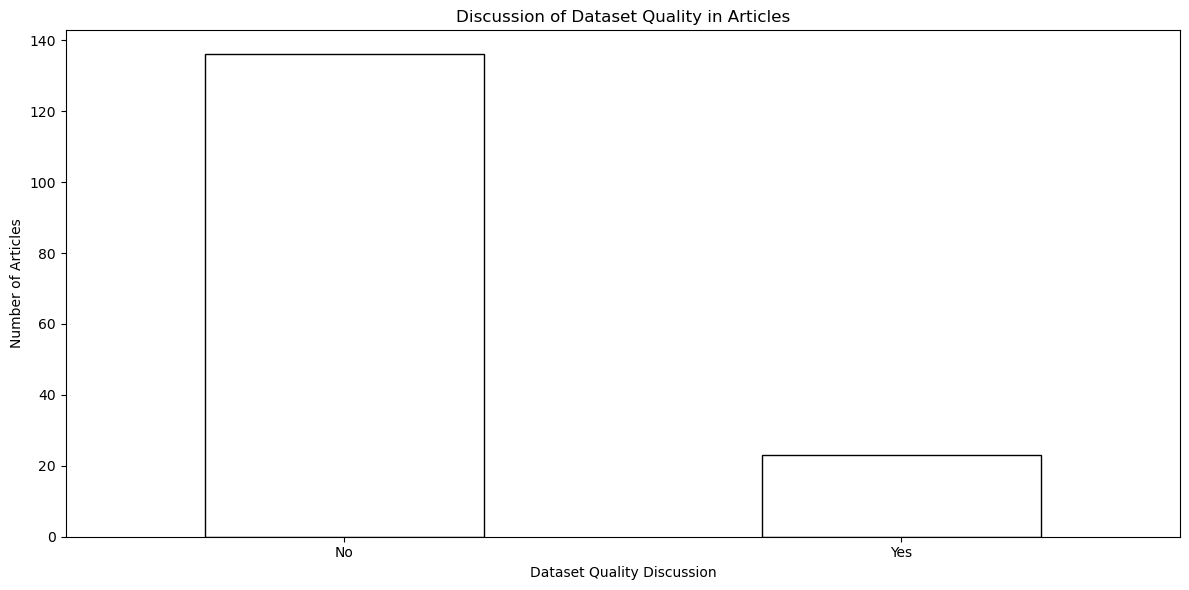

Is dataset quality discussed in article?
No     136
Yes     23
Name: count, dtype: int64

In [24]:
# plot 'Is dataset quality discussed in article?'
plt.figure(figsize=(12, 6))
df['Is dataset quality discussed in article?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Discussion of Dataset Quality in Articles')
plt.xlabel('Dataset Quality Discussion')
plt.ylabel('Number of Articles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Count the occurrences of each dataset quality discussion
df['Is dataset quality discussed in article?'].value_counts()

## 2.11 Out of Sample Testing Applied

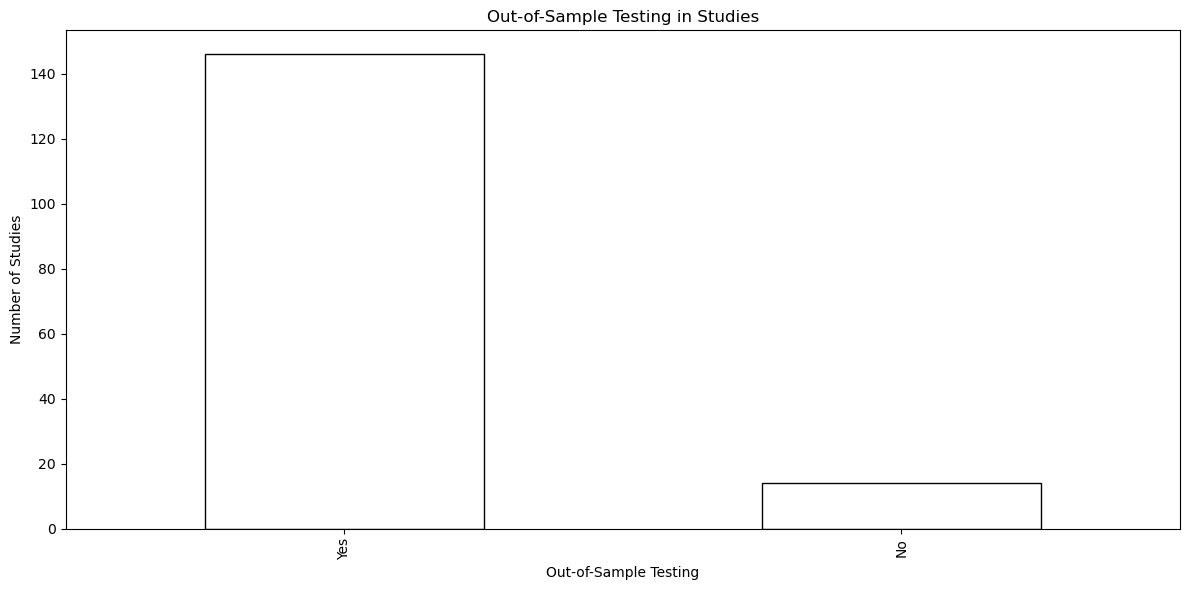

Is out-of-sample testing applied?
Yes    146
No      14
Name: count, dtype: int64

In [25]:
# plot  'Is out-of-sample testing applied?
plt.figure(figsize=(12, 6))
df['Is out-of-sample testing applied?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Out-of-Sample Testing in Studies')
plt.xlabel('Out-of-Sample Testing')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
# Count the occurrences of out-of-sample testing
df['Is out-of-sample testing applied?'].value_counts()

## 2.12 Diverse Test Sets

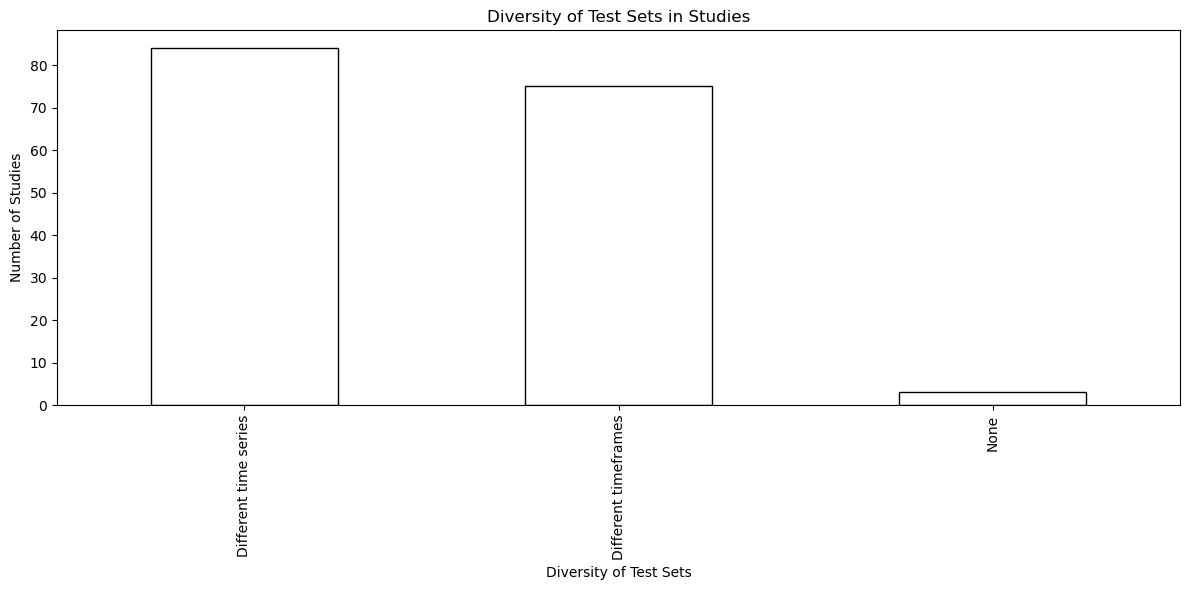

Was the model tested on diverse test sets?
Different time series    84
Different timeframes     75
None                      3
Name: count, dtype: int64

In [26]:
# split the 'Was the model tested on diverse test sets?' column into a list of types by splitting on semicolon and stripping whitespace
test_sets = df['Was the model tested on diverse test sets?'].dropna().str.split(';').explode().str.strip()

# plot 'Was the model tested on diverse test sets?'
plt.figure(figsize=(12, 6))
test_sets.value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Diversity of Test Sets in Studies')
plt.xlabel('Diversity of Test Sets')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Count the occurrences of each type of test set
test_sets.value_counts()

## 2.13 Different Datasets or Applications

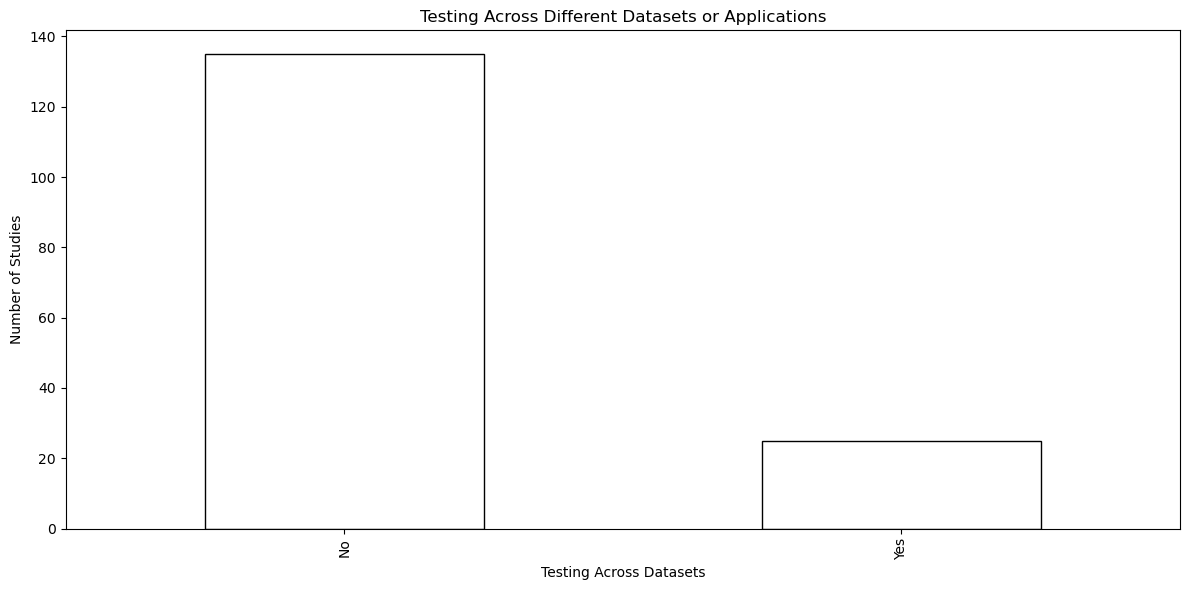

Was the model tested across different datasets or applications?
No     135
Yes     25
Name: count, dtype: int64

In [27]:
# plot 'Was the model tested across different datasets or applications?'

plt.figure(figsize=(12, 6))
df['Was the model tested across different datasets or applications?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Testing Across Different Datasets or Applications')
plt.xlabel('Testing Across Datasets')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
# Count the occurrences of testing across different datasets or applications
df['Was the model tested across different datasets or applications?'].value_counts()

## 2.14 Non-Stationarity Discussed

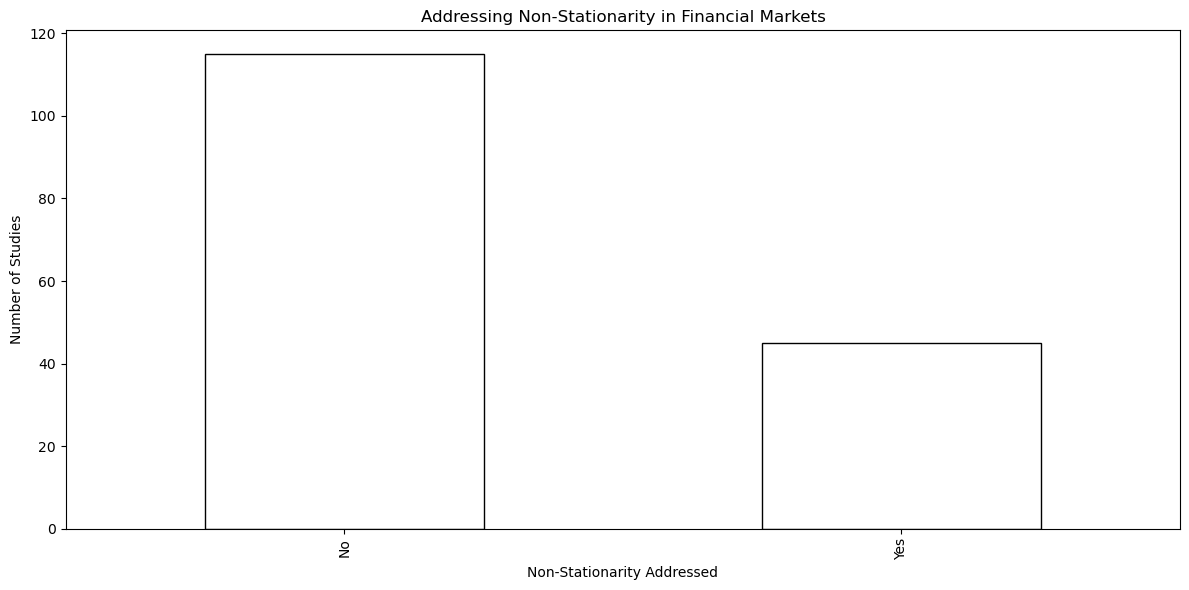

Is the non-stationarity problem of financial markets explicitly addressed?
No     115
Yes     45
Name: count, dtype: int64

In [28]:
# plot 'Is the non-stationarity problem of financial markets explicitly addressed?'
plt.figure(figsize=(12, 6))
df['Is the non-stationarity problem of financial markets explicitly addressed?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Addressing Non-Stationarity in Financial Markets')
plt.xlabel('Non-Stationarity Addressed')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Count the occurrences of addressing non-stationarity
df['Is the non-stationarity problem of financial markets explicitly addressed?'].value_counts()

## 2.15 HP Tuning Explained

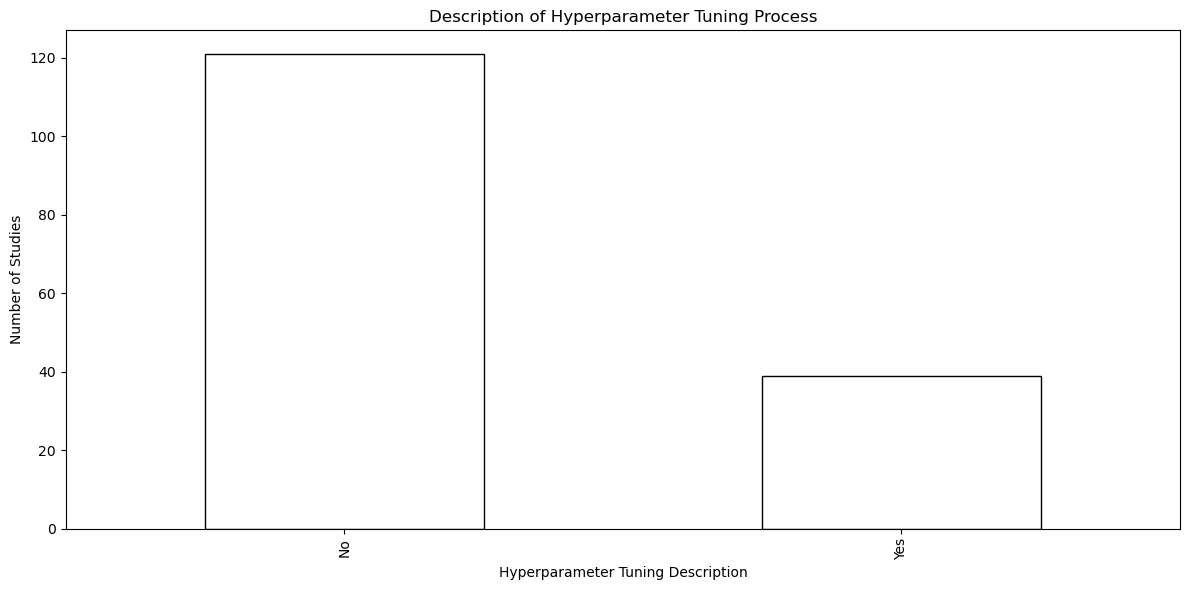

Is the process of hyperparameter tuning explicitly described?
No     121
Yes     39
Name: count, dtype: int64

In [29]:
# plot  'Is the process of hyperparameter tuning explicitly described?'
plt.figure(figsize=(12, 6))
df['Is the process of hyperparameter tuning explicitly described?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Description of Hyperparameter Tuning Process')
plt.xlabel('Hyperparameter Tuning Description')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
# Count the occurrences of hyperparameter tuning description
df['Is the process of hyperparameter tuning explicitly described?'].value_counts()


## 2.16 Evaluation Metrics

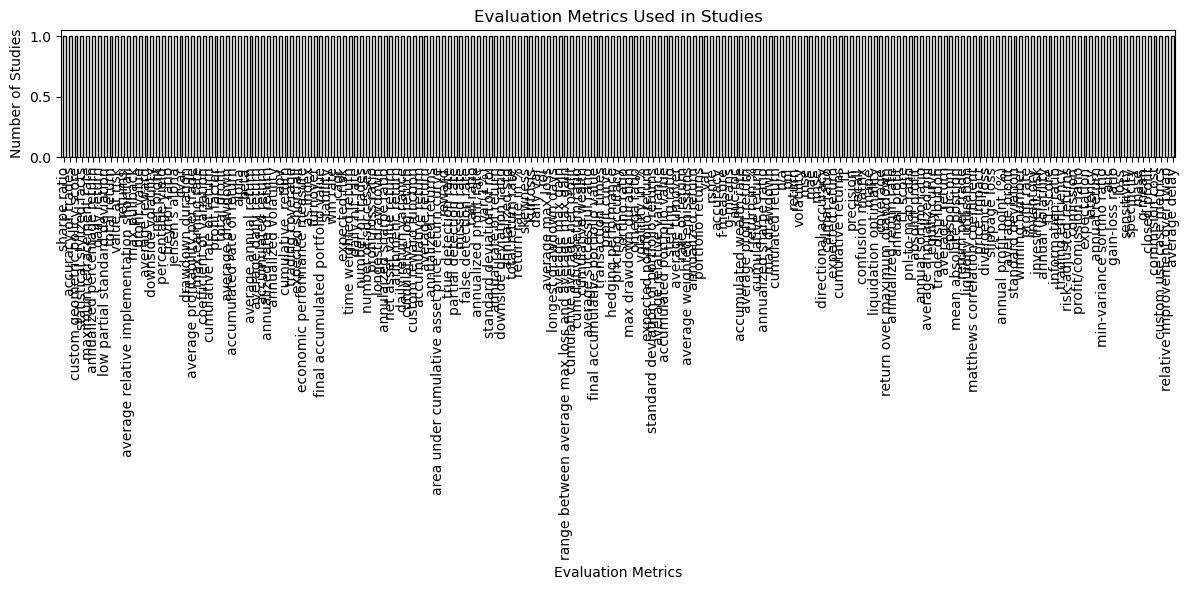

Which evaluation metrics are used?
sharpe ratio                      1
accuracy of trades                1
custom geometric policy score     1
statistical stylized facts        1
maximum retracement rate          1
                                 ..
closed profit                     1
commision cost                    1
custom use case metrics           1
relative improvement over twap    1
average delay                     1
Name: count, Length: 191, dtype: int64

In [89]:
# split the 'Which evaluation metrics are used?' column into a list of metrics by splitting on semicolon and on comma and remove 'Other: ' and stripping whitespace
metrics_list = df['Which evaluation metrics are used?'].dropna().str.split(';|,').explode().str.strip().str.replace('Other: ', '', regex=False)

# clean up the metrics_list by removing any leading or trailing whitespace and convert to lowercase
metrics_list = metrics_list.str.strip().str.lower()

# remove duplicate entries
metrics_list = metrics_list.drop_duplicates()


# plot 'Which evaluation metrics are used?'
plt.figure(figsize=(12, 6))
metrics_list.value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Evaluation Metrics Used in Studies')
plt.xlabel('Evaluation Metrics')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

metrics_list.value_counts()

191 different values. Some of them might be the same. This is not clear as not all papers defined the metrics clearly.

In [90]:
# print all metrics that contain 'return'
return_metrics = metrics_list[metrics_list.str.contains('return', case=False, na=False)]
print("Metrics related to 'return':")

# turn into sorted list
return_metrics = return_metrics.tolist()
return_metrics.sort()
print(return_metrics)

print(return_metrics[3], return_metrics[4])

Metrics related to 'return':
['accumulated rate of return', 'accumulated return', 'accumulative return', 'annual rate of return', 'annual return', 'annualized percentage return', 'annualized rate of return', 'annualized return', 'annualized return rate', 'annualized returns', 'area under cumulative asset price return curve', 'arithmetic return', 'average  return', 'average annual return', 'average daily return', 'average profit return', 'average return', 'cumulated return', 'cumulative  return', 'cumulative log return', 'cumulative rate of return', 'cumulative return', 'cumulative return ratio', 'cumulative returns', 'daily return', 'daily return variance', 'expected portfolio return', 'expected return', 'net asset value return', 'portfolio returns', 'rate of return', 'return', 'return in %', 'return over maximum drawdown', 'return per trade', 'return rate in %', 'returns', 'risk-adjusted returns', 'standard deviation of portfolio returns', 'time weighted return', 'total return', 'tota

In [ ]:
# print study and title of rows that use specifc metric from return_metrics

target_metrics = [return_metrics[i] for i in [2, 18, 19, 20, 21, 23]]

for target_metric in target_metrics:
    # Build exact word match pattern
    pattern = rf'\b{re.escape(target_metric.lower())}\b'

    filtered_df = df[df['Which evaluation metrics are used?']
                     .str.lower()
                     .str.contains(pattern, regex=True, na=False)]

    print(f"\nStudies using the metric '{target_metric}':")
    print(filtered_df[['Study ID', 'Title']])



Studies using the metric 'accumulative return':
     Study ID                                              Title
155  Liu2024b  Revolutionising Financial Portfolio Management...

Studies using the metric 'cumulative  return':
      Study ID                                              Title
68    Jing2024  Automated cryptocurrency trading approach usin...
119  Park2024a  Twin-system recurrent reinforcement learning f...

Studies using the metric 'cumulative log return':
    Study ID                                              Title
154   He2024  High-Frequency Quantitative Trading of Digital...

Studies using the metric 'cumulative rate of return':
      Study ID                                              Title
66  Huang2024a  Trading Strategy of the Cryptocurrency Market ...

Studies using the metric 'cumulative return':
         Study ID                                              Title
10      Huang2023  DADE-DQN: Dual Action and Dual Environment Dee...
16       Park2020  An in

## 2.17 Validation with Statistical Tests or Confidence Intervals

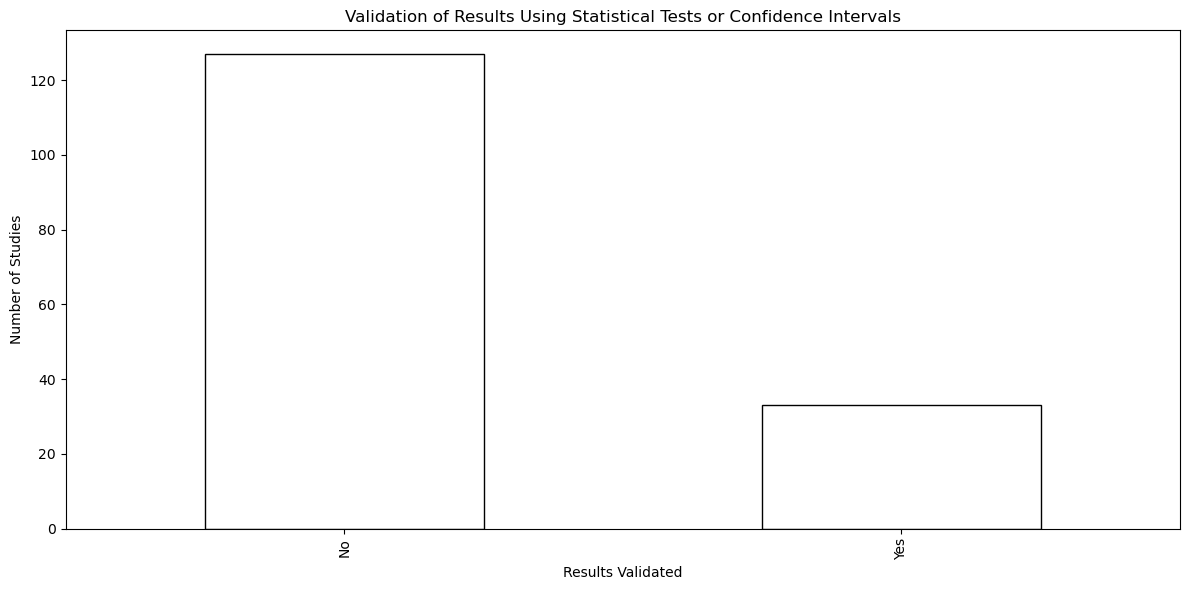

Are results validated using statistical tests or confidence intervals?
No     127
Yes     33
Name: count, dtype: int64

In [31]:
# plot 'Are results validated using statistical tests or confidence intervals?'
plt.figure(figsize=(12, 6))
df['Are results validated using statistical tests or confidence intervals?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Validation of Results Using Statistical Tests or Confidence Intervals')
plt.xlabel('Results Validated')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
# Count the occurrences of results validation
df['Are results validated using statistical tests or confidence intervals?'].value_counts()

## 2.18 Conducts Benchmark

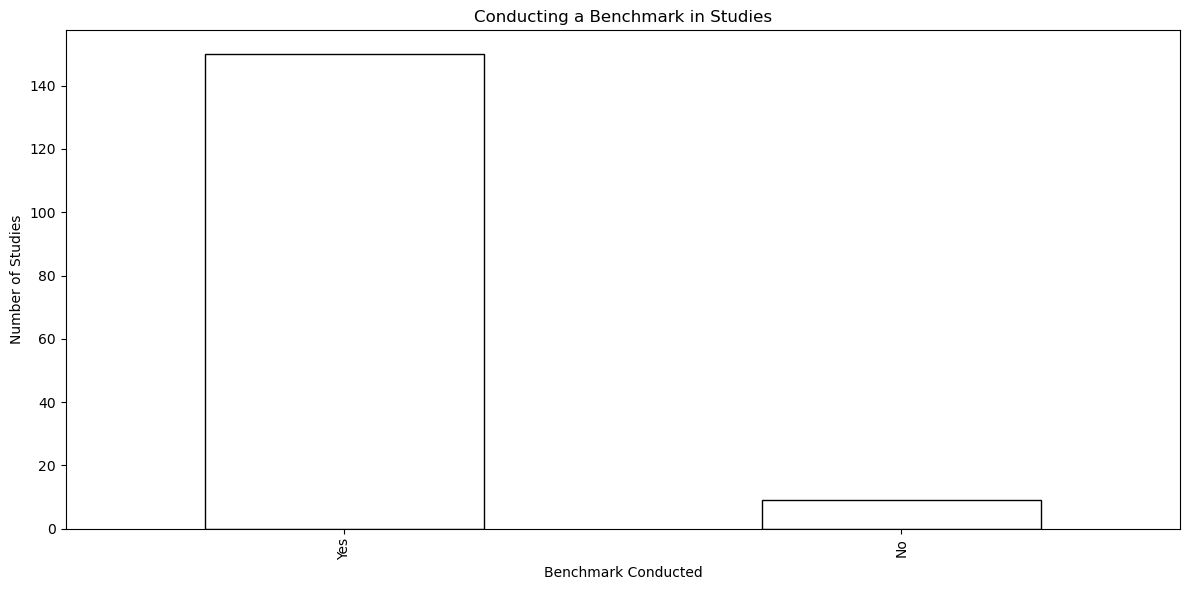

Does the study conduct a benchmark?
Yes    150
No       9
Name: count, dtype: int64

In [32]:
# plot 'Does the study conduct a benchmark?'
plt.figure(figsize=(12, 6))
df['Does the study conduct a benchmark?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Conducting a Benchmark in Studies')
plt.xlabel('Benchmark Conducted')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
# Count the occurrences of benchmark conducted
df['Does the study conduct a benchmark?'].value_counts()

## 2.19 Benchmarked Against What

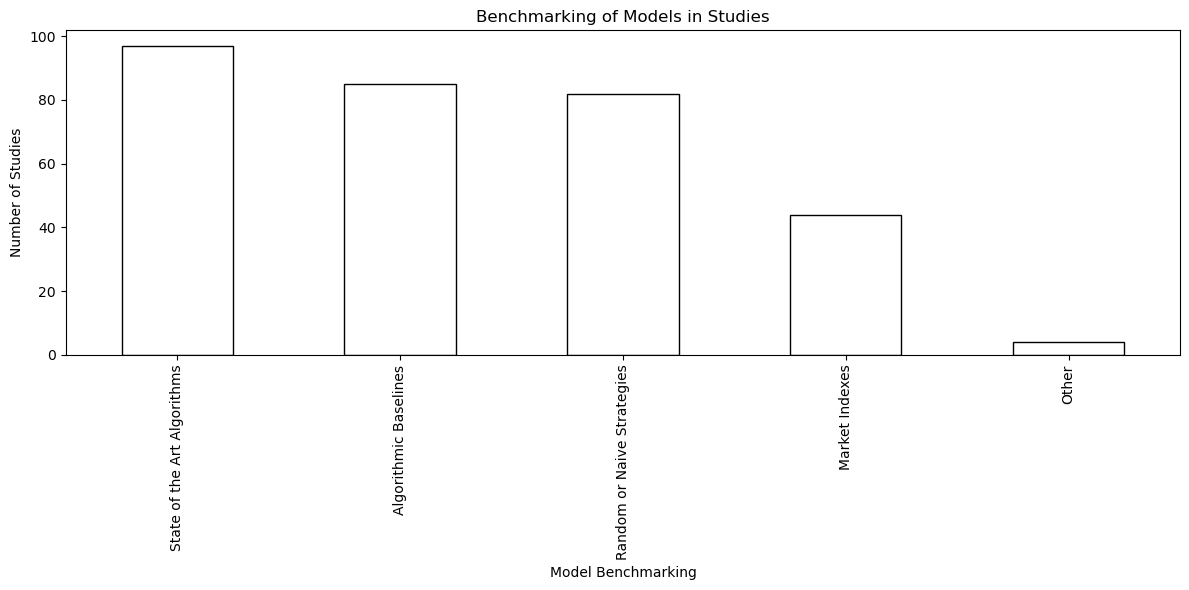

What is the model benchmarked against?
State of the Art Algorithms    97
Algorithmic Baselines          85
Random or Naive Strategies     82
Market Indexes                 44
Other                           4
Name: count, dtype: int64

In [33]:
# split the 'What is the model benchmarked against?' column into a list of metrics by splitting on semicolon and on comma and remove 'Other: ' and stripping whitespace
benchmark_list = df['What is the model benchmarked against?'].dropna().str.split(';').explode().str.strip()

# standardize to 'Other' if it contains 'other'
benchmark_list = benchmark_list.apply(lambda x: 'Other' if 'other' in x.lower() else x)

# plot 'What is the model benchmarked against?'
plt.figure(figsize=(12, 6))
benchmark_list.value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Benchmarking of Models in Studies')
plt.xlabel('Model Benchmarking')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
# Count the occurrences of model benchmarking
benchmark_list.value_counts()

## 2.20 Standard Dataset Used 

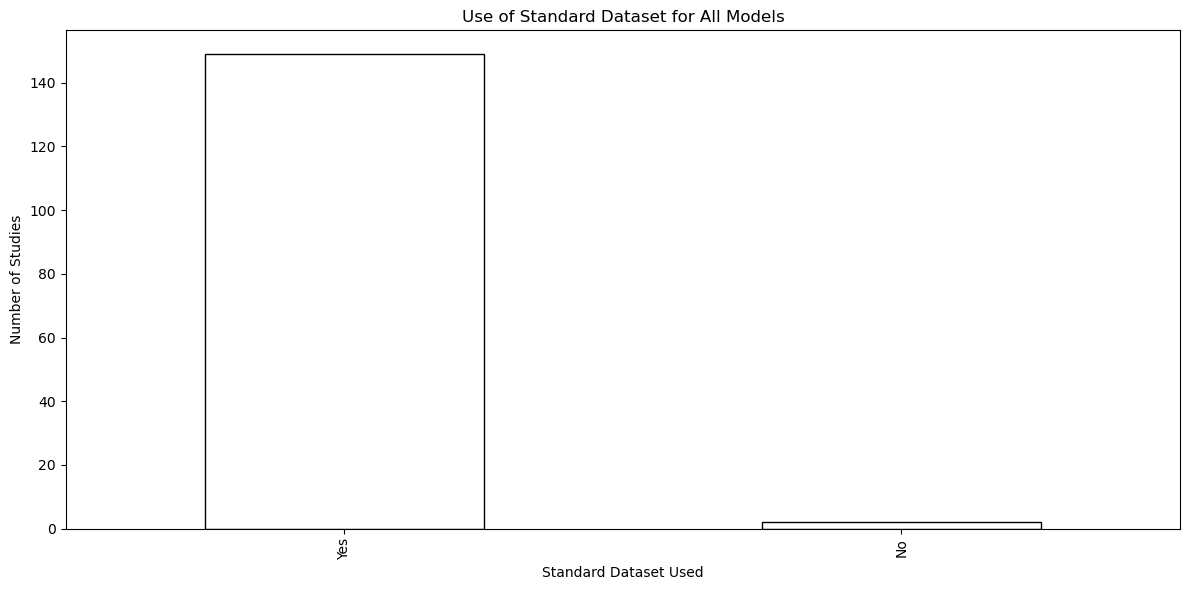

Is a standard dataset used for all models?
Yes    149
No       2
Name: count, dtype: int64

In [34]:
# plot 'Is a standard dataset used for all models?'
plt.figure(figsize=(12, 6))
df['Is a standard dataset used for all models?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Use of Standard Dataset for All Models')
plt.xlabel('Standard Dataset Used')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
# Count the occurrences of standard dataset used
df['Is a standard dataset used for all models?'].value_counts()

In [75]:
# Filter FOR the claim: Out-of-sample testing + Tested on diverse test sets or datasets + Statistical validation
for_testing_validation = df[
    (df['Is out-of-sample testing applied?'].str.contains('yes', case=False, na=False)) &
    (
        df['Was the model tested on diverse test sets?'].str.contains('yes', case=False, na=False) |
        df['Was the model tested across different datasets or applications?'].str.contains('yes', case=False, na=False)
    ) &
    (df['Are results validated using statistical tests or confidence intervals?'].str.contains('yes', case=False, na=False))
][['Study ID', 'Title']]

# Filter AGAINST the claim: No out-of-sample testing OR No diverse test sets AND No different datasets OR No statistical validation
against_testing_validation = df[
    (df['Is out-of-sample testing applied?'].str.contains('no', case=False, na=False)) |
    (
        (df['Was the model tested on diverse test sets?'].str.contains('no', case=False, na=False)) &
        (df['Was the model tested across different datasets or applications?'].str.contains('no', case=False, na=False))
    ) |
    (df['Are results validated using statistical tests or confidence intervals?'].str.contains('no', case=False, na=False))
][['Study ID', 'Title']]

# Display results
print("Examples FOR the Testing and Validation claim:")
print(for_testing_validation)

print("\nExamples AGAINST the Testing and Validation claim:")
print(against_testing_validation)


Examples FOR the Testing and Validation claim:
        Study ID                                              Title
30     Kumar2024  Early MTS Forecasting for Dynamic Stock Predic...
135  Ansari 2024  A Multifaceted Approach to Stock Market Tradin...

Examples AGAINST the Testing and Validation claim:
            Study ID                                              Title
0          Chen2024b  Portfolio Allocation with Dynamic Risk Prefere...
1         Hambly2023  Recent advances in reinforcement learning in f...
2      Barbieri 2020  Discrete-Event Simulation-Based Q-Learning Alg...
3             Li2021  Take Bitcoin into your portfolio: a novel ense...
4           Song2024  Developing an investment method for securities...
..               ...                                                ...
158    Felizardo2022  Outperforming algorithmic trading reinforcemen...
159        Park2024b  Deep Reinforcement Learning Robots for Algorit...
160  Aboussalah 2020  Continuous control with Sta

# 3 Results Analysis

## 3.1 Data Shared

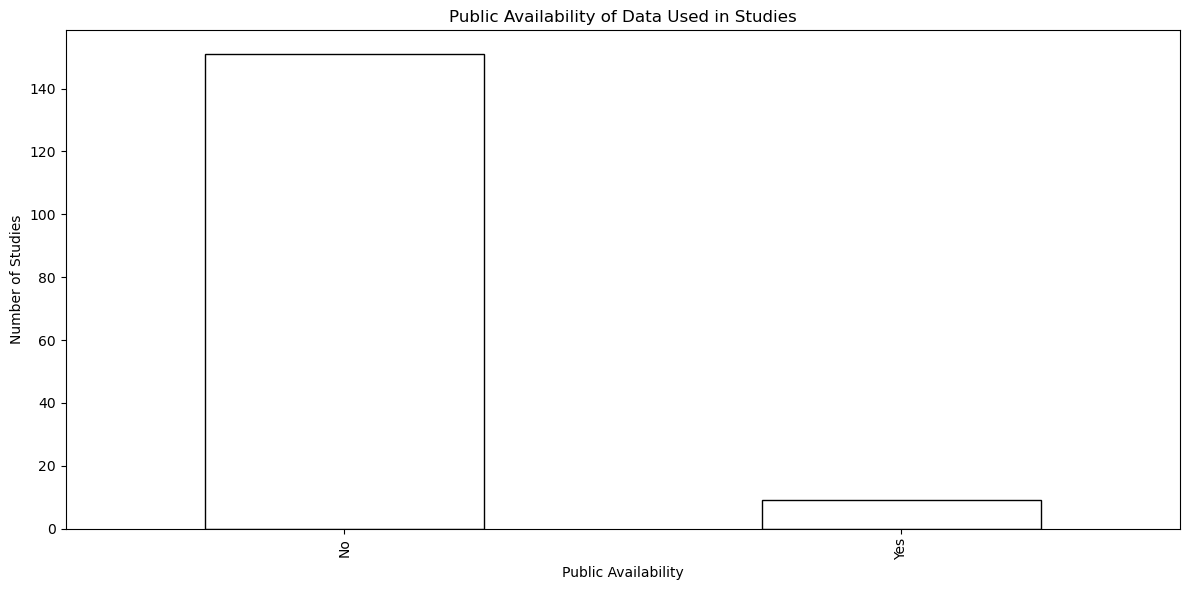

Is all used and produced data made publicly available and referred to in the article?
No     151
Yes      9
Name: count, dtype: int64

In [35]:
# plot 'Is all used and produced data made publicly available and referred to in the article?'

plt.figure(figsize=(12, 6))
df['Is all used and produced data made publicly available and referred to in the article?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Public Availability of Data Used in Studies')
plt.xlabel('Public Availability')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
# Count the occurrences of public availability of data
df['Is all used and produced data made publicly available and referred to in the article?'].value_counts()

## 3.2 All Performance Results Shared

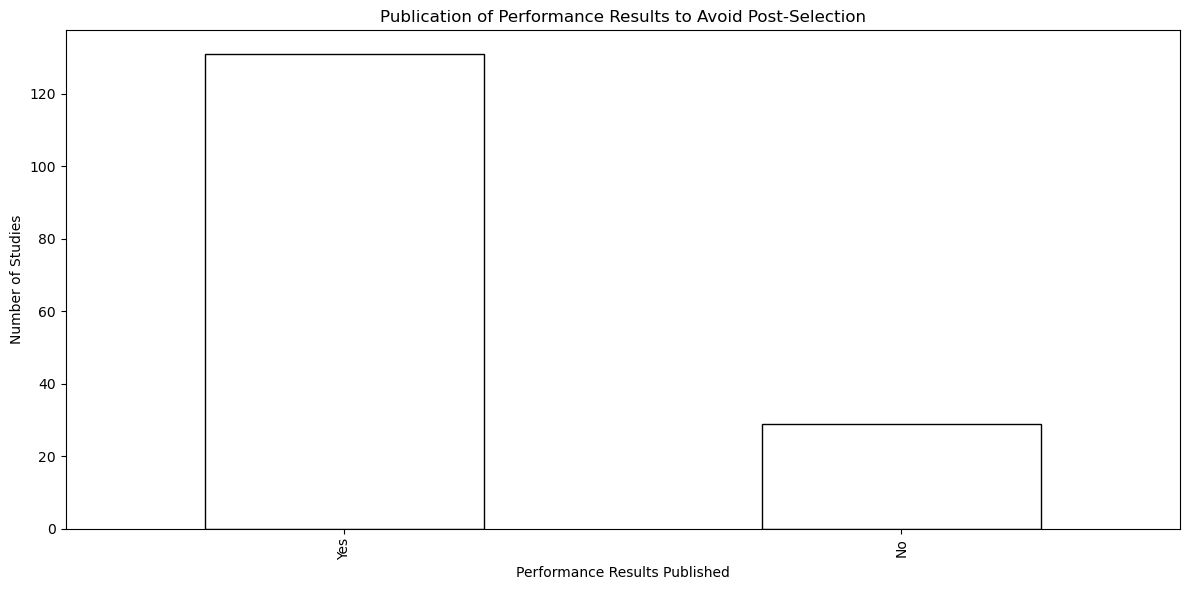

Are all performance results published to avoid post-selection?
Yes    131
No      29
Name: count, dtype: int64

In [36]:
# plot 'Are all performance results published to avoid post-selection?'
plt.figure(figsize=(12, 6))
df['Are all performance results published to avoid post-selection?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Publication of Performance Results to Avoid Post-Selection')
plt.xlabel('Performance Results Published')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
# Count the occurrences of performance results published
df['Are all performance results published to avoid post-selection?'].value_counts()


## 3.3 Code Available

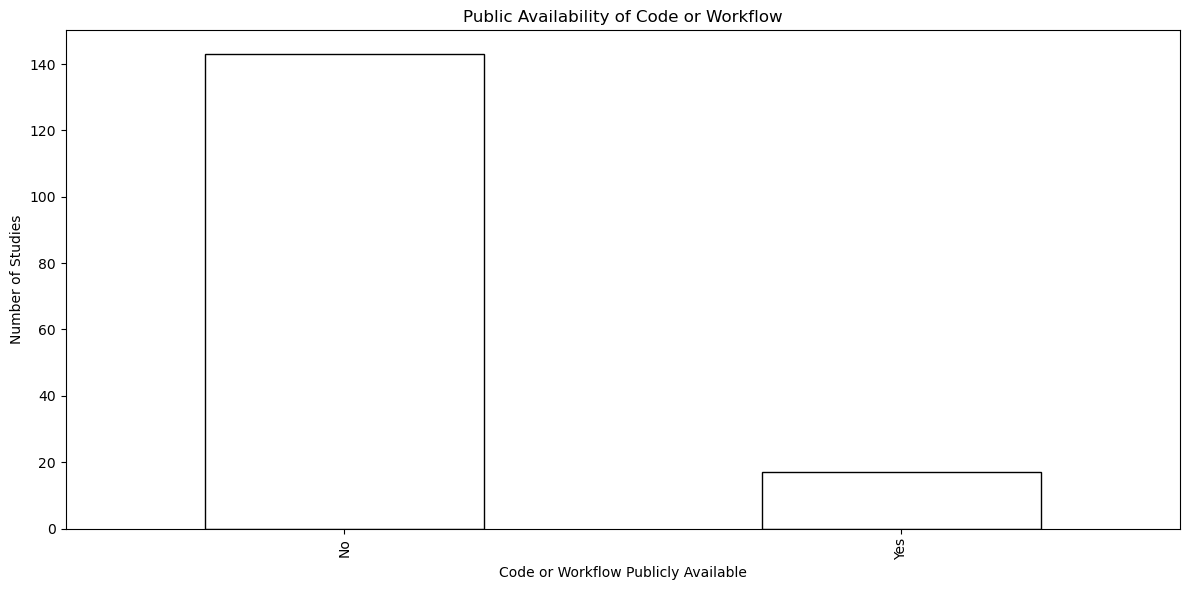

Is the code or workflow made publicly available and referred to?
No     143
Yes     17
Name: count, dtype: int64

In [37]:
# plot 'Is the code or workflow made publicly available and referred to?'
plt.figure(figsize=(12, 6))
df['Is the code or workflow made publicly available and referred to?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Public Availability of Code or Workflow')
plt.xlabel('Code or Workflow Publicly Available')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Count the occurrences of code or workflow publicly available
df['Is the code or workflow made publicly available and referred to?'].value_counts()

In [38]:
# print Study IDs and Title of studies where code is available
print("Studies with publicly available code:")
df[df['Is the code or workflow made publicly available and referred to?'] == 'Yes'][['Study ID', 'Title']]

Studies with publicly available code:


,Study ID,Title
8,Carta 2021a,A multi-layer and multi-ensemble stock trader ...
34,Kochliaridis2023,Combining deep reinforcement learning with tec...
45,Lee2023,Offline Reinforcement Learning for Automated S...
46,Zengeler2020,Contracts for Difference: A Reinforcement Lear...
54,Marzban2023a,Deep reinforcement learning for option pricing...
60,Kochliaridis2024,UNSURE - A machine learning approach to crypto...
65,Chakole 2021,A Q-learning agent for automated trading in eq...
68,Jing2024,Automated cryptocurrency trading approach usin...
72,Gasperov2022,Deep Reinforcement Learning for Market Making ...
78,Giorgi2023,A reinforcement learning algorithm for trading...


## 3.4 Implementation Status

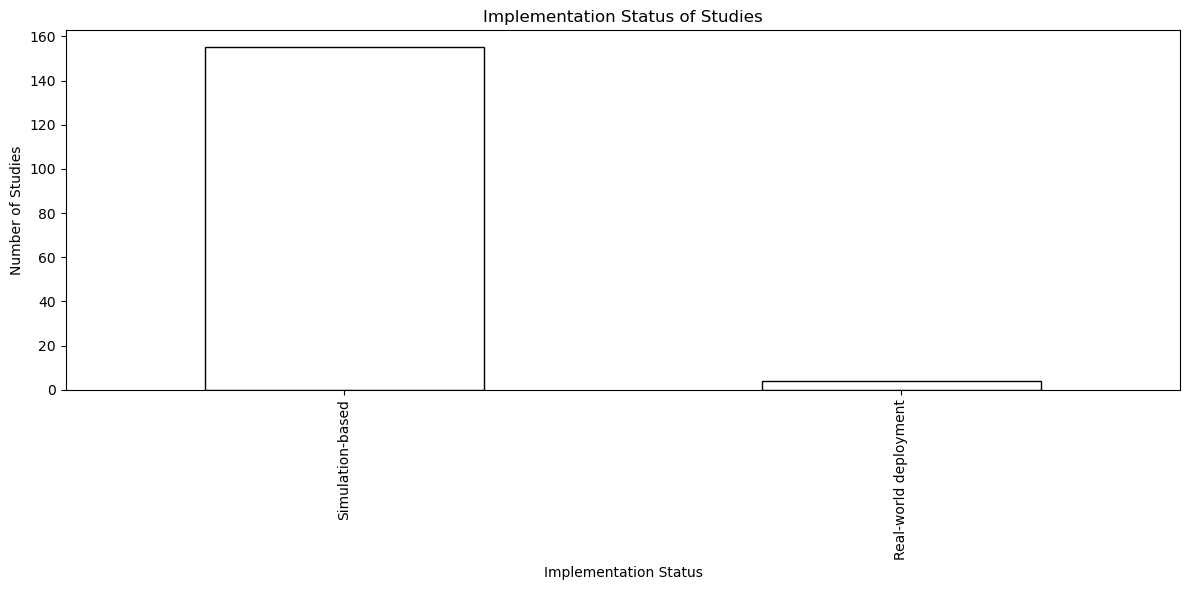

What is the implementation status?
Simulation-based         155
Real-world deployment      4
Name: count, dtype: int64

In [39]:
# plot 'What is the implementation status?'
plt.figure(figsize=(12, 6))
df['What is the implementation status?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Implementation Status of Studies')
plt.xlabel('Implementation Status')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Count the occurrences of implementation status
df['What is the implementation status?'].value_counts()


In [100]:
# print studyID and title of rows with real-world implementation
print("Studies with Real-World Implementation:")
print(df[df['What is the implementation status?'] == 'Real-world deployment'][['Study ID', 'Title']])

Studies with Real-World Implementation:
        Study ID                                              Title
29    Zhang2022b  Auto uning of price prediction models for high...
31    Zhang2022a  TradeBot: Bandit learning for hyper-parameters...
40     Zhang2023  Reinforcement Learning for Stock Prediction an...
46  Zengeler2020  Contracts for Difference: A Reinforcement Lear...


C:\Users\JanderM\AppData\Local\Temp\ipykernel_31652\1219749111.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['outperform claim'] = df['What are the stated key results of the study?'].str.contains('outperform', case=False, na=False)


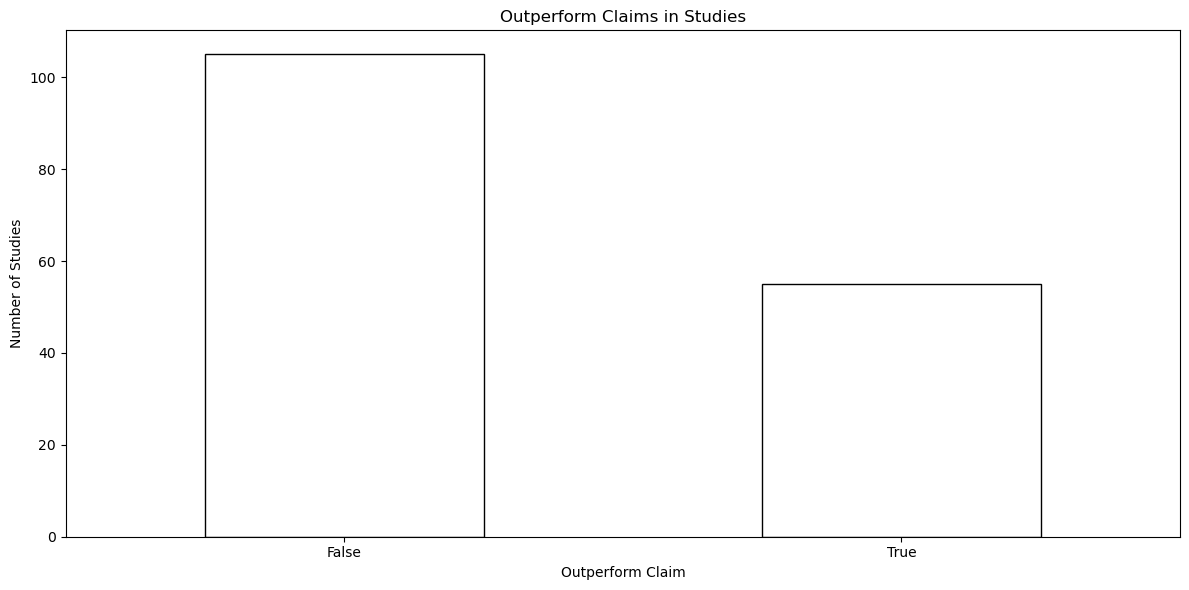

outperform claim
False    105
True      55
Name: count, dtype: int64

In [40]:
# create new column 'outperform claim' with boolean values based on 'What are the stated key results of the study?' containing 'outperform'
df['outperform claim'] = df['What are the stated key results of the study?'].str.contains('outperform', case=False, na=False)

# plot 'outperform claim'
plt.figure(figsize=(12, 6))
df['outperform claim'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Outperform Claims in Studies')
plt.xlabel('Outperform Claim')
plt.ylabel('Number of Studies')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# plot value counts of 'outperform claim'
df['outperform claim'].value_counts()


In [41]:
df['What are the stated limitations of the study?']

0                                                   none
2                                                   none
3      Framework only uses structured data as input.\...
4      Ability to adapt to high dimension and rapidly...
5      Possibly overlooked influential data sources.\...
                             ...                        
158                                                 none
159                                                 none
160          limited size of training and testing window
161                                                 none
162                                                 none
Name: What are the stated limitations of the study?, Length: 160, dtype: object

In [42]:
# count number of rows where 'What are the stated limitations of the study?' is 'None'
limitations_none_count = df['What are the stated limitations of the study?'].str.contains('none', case=False, na=False).sum()
print(f"Number of studies with no stated limitations: {limitations_none_count}")

Number of studies with no stated limitations: 105


# 4 Other

In [43]:
# load the cleaned output CSV file again to include literature reviews again

df = pd.read_csv('cleaned_output.csv')

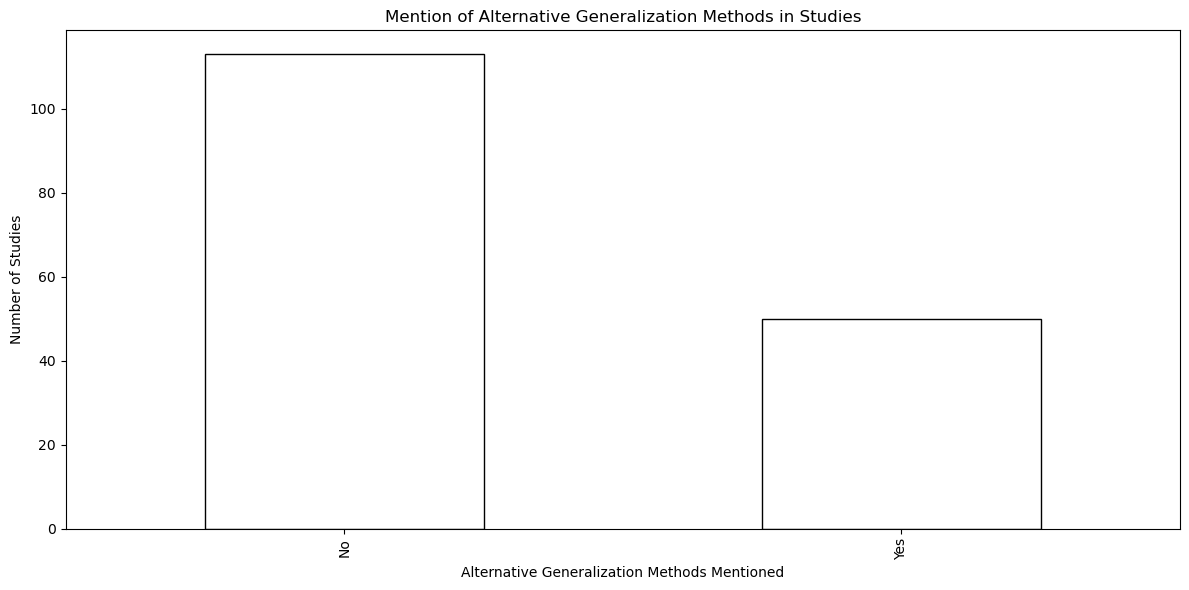

In [44]:
# plot 'Does study mention alternative generalization methods?'
plt.figure(figsize=(12, 6))
df['Does study mention alternative generalization methods?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Mention of Alternative Generalization Methods in Studies')
plt.xlabel('Alternative Generalization Methods Mentioned')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


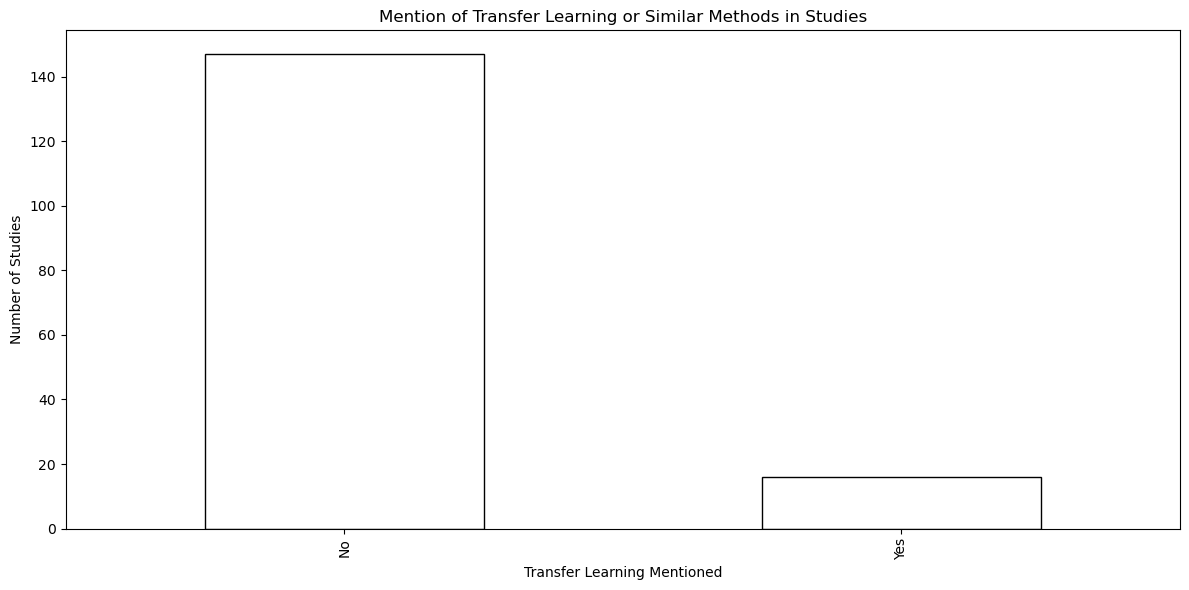

In [45]:
# plot 'Does study mention Transfer Learning or similar method as potential avenue for research?'
plt.figure(figsize=(12, 6))
df['Does study mention Transfer Learning or similar method as potential avenue for research?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Mention of Transfer Learning or Similar Methods in Studies')
plt.xlabel('Transfer Learning Mentioned')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

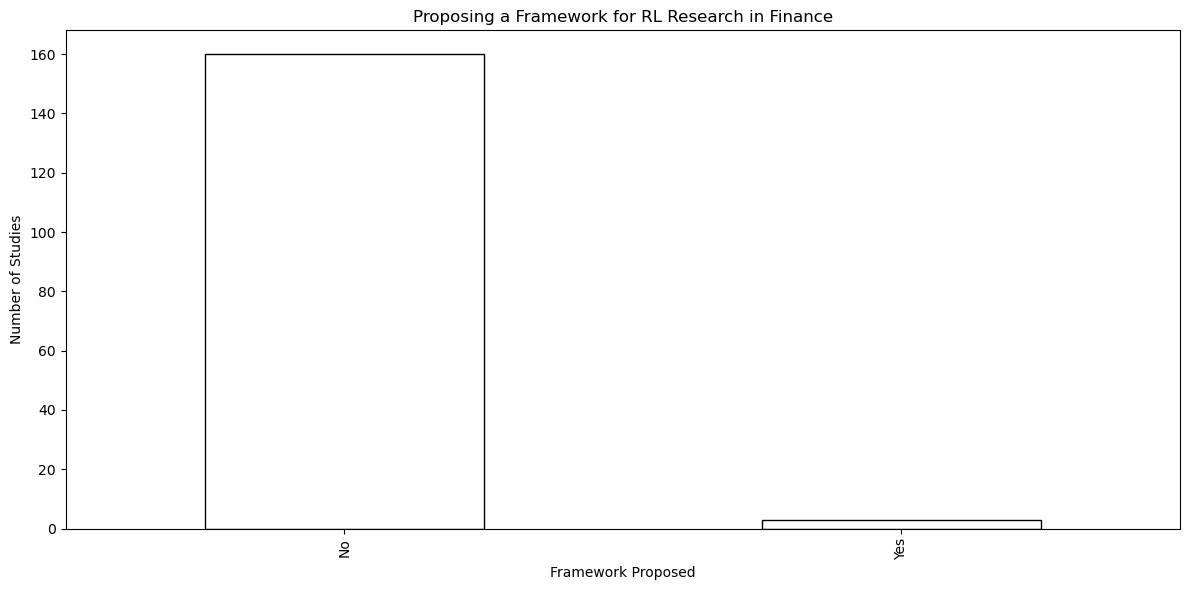

In [46]:
# plot 'Does the study propose a framework to structure RL research in finance?'
plt.figure(figsize=(12, 6))
df['Does the study propose a framework to structure RL research in finance?'].value_counts().plot(kind='bar', color='white', edgecolor='black')
plt.title('Proposing a Framework for RL Research in Finance')
plt.xlabel('Framework Proposed')
plt.ylabel('Number of Studies')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [47]:
# print papers that propose a framework to structure RL research in finance
print("Studies proposing a framework to structure RL research in finance:")
print(df[df['Does the study propose a framework to structure RL research in finance?'] == 'Yes'][['Study ID', 'Title']])

Studies proposing a framework to structure RL research in finance:
            Study ID                                              Title
1         Hambly2023  Recent advances in reinforcement learning in f...
39  Charpentier 2023    Reinforcement Learning in Economics and Finance
89          Sun2023b    Reinforcement Learning for Quantitative Trading


In [48]:
df.columns

Index(['Covidence #', 'Title', 'Reviewer Name', 'Study ID',
       'Journal Subject Area (Scimago classification)',
       'What is the type of study?', 'What are the objectives of the study?',
       'Which RL technique is used?', 'Which finance application is tested?',
       'What are the stated key results of the study?',
       'What are the stated limitations of the study?',
       'What asset classes are in the dataset?',
       'What are the number of assets in the dataset?',
       'What is the nature of the asset price dataset?',
       'What is the granularity of the price dataset?',
       'What is the format of the price dataset?',
       'What other datasets are used in the study?',
       'What is the time frame of time series data used?:', 'Date Start',
       'Date End',
       'Is all used and produced data made publicly available and referred to in the article?',
       'Which continents are represented in the price dataset?',
       'Is dataset quality discussed in 